## **Problem Statement**

### **Business Context**

An automobile dealership in Los Vegas specializes in selling luxury and non-luxury vehicles. They cater to diverse customer preferences with varying vehicle specifications, such as mileage, engine capacity, and seating capacity. However, the dealership faces significant challenges in maintaining consistency and efficiency across its pricing strategy due to reliance on manual processes and disconnected systems. Pricing evaluations are prone to errors, updates are delayed, and scaling operations are difficult as demand grows. These inefficiencies impact revenue and customer trust. Recognizing the need for a reliable and scalable solution, the dealership is seeking to implement a unified system that ensures seamless integration of data-driven pricing decisions, adaptability to changing market conditions, and operational efficiency.

### **Objective**

The dealership has hired you as an MLOps Engineer to design and implement an MLOps pipeline that automates the pricing workflow. This pipeline will encompass data cleaning, preprocessing, transformation, model building, training, evaluation, and registration with CI/CD capabilities to ensure continuous integration and delivery. Your role is to overcome challenges such as integrating disparate data sources, maintaining consistent model performance, and enabling scalable, automated updates to meet evolving business needs. The expected outcomes are a robust, automated system that improves pricing accuracy, operational efficiency, and scalability, driving increased profitability and customer satisfaction.

### **Data Description**

The dataset contains attributes of used cars sold in various locations. These attributes serve as key data points for CarOnSell's pricing model. The detailed attributes are:

- **Segment:** Describes the category of the vehicle, indicating whether it is a luxury or non-luxury segment.

- **Kilometers_Driven:** The total number of kilometers the vehicle has been driven.

- **Mileage:** The fuel efficiency of the vehicle, measured in kilometers per liter (km/l).

- **Engine:** The engine capacity of the vehicle, measured in cubic centimeters (cc).

- **Power:** The power of the vehicle's engine, measured in brake horsepower (BHP).

- **Seats:** The number of seats in the vehicle, can influence the vehicle's classification, usage, and pricing based on customer needs.

- **Price:** The price of the vehicle, listed in lakhs (units of 100,000), represents the cost to the consumer for purchasing the vehicle.

## **1. AzureML Environment Setup and Data Preparation**

### **1.1 Connect to Azure Machine Learning Workspace**

In [ ]:
# Handle to the workspace
from azure.ai.ml import MLClient

# Authentication package
from azure.identity import DefaultAzureCredential
credential = DefaultAzureCredential()

In [ ]:
# Get a handle to the workspace
ml_client = MLClient(
    credential=credential,
    subscription_id="<<>>",
    resource_group_name="gl_resource_grp",
    workspace_name="FitwellWorkspace",
)

### **1.2 Set Up Compute Cluster**

In [ ]:
from azure.ai.ml.entities import AmlCompute

# Name assigned to the compute cluster
cpu_compute_target = "cpu-cluster"

try:
    # let's see if the compute target already exists
    cpu_cluster = ml_client.compute.get(cpu_compute_target)
    print(
        f"You already have a cluster named {cpu_compute_target}, we'll reuse it as is."
    )

except Exception:
    print("Creating a new cpu compute target...")

    # Let's create the Azure ML compute object with the intended parameters
    cpu_cluster = AmlCompute(
        name=cpu_compute_target,
        # Azure ML Compute is the on-demand VM service
        type="amlcompute",
        # VM Family
        size="Standard_DS11_v2",
        # Minimum running nodes when there is no job running
        min_instances=0,
        # Nodes in cluster
        max_instances=1,
        # How many seconds will the node running after the job termination
        idle_time_before_scale_down=180,
        # Dedicated or LowPriority. The latter is cheaper but there is a chance of job termination
        tier="Dedicated",
    )

    # Now, we pass the object to MLClient's create_or_update method
    cpu_cluster = ml_client.compute.begin_create_or_update(cpu_cluster).result()

print(
    f"AMLCompute with name {cpu_cluster.name} is created, the compute size is {cpu_cluster.size}"
)

You already have a cluster named cpu-cluster, we'll reuse it as is.
AMLCompute with name cpu-cluster is created, the compute size is Standard_DS11_v2


### **1.3 Register Dataset as Data Asset**

In [ ]:
from azure.ai.ml.entities import Data
from azure.ai.ml.constants import AssetTypes

# Path to the local dataset
local_data_path = 'used_cars.csv'

# Create and register the dataset as an AzureML data asset
data_asset = Data(
    path=local_data_path,
    type=AssetTypes.URI_FILE,
    description="A dataset of used cars for price prediction",
    name="used-cars-data"
)

In [ ]:
ml_client.data.create_or_update(data_asset)

### **1.4 Create and Configure Job Environment**

In [ ]:
# Create a directory for the preprocessing script
import os

src_dir_env = "./env"
os.makedirs(src_dir_env, exist_ok=True)

In [ ]:
%%writefile {src_dir_env}/conda.yml
name: sklearn-env
channels:
  - conda-forge
dependencies:
  - python=3.8
  - pip=21.2.4
  - scikit-learn=0.23.2
  - scipy=1.7.1
  - pip:
    - mlflow==2.8.1
    - azureml-mlflow==1.51.0
    - azureml-inference-server-http
    - azureml-core==1.49.0
    - cloudpickle==1.6.0

Overwriting ./env/conda.yml


In [ ]:
from azure.ai.ml.entities import Environment, BuildContext

env_docker_conda = Environment(
    image="mcr.microsoft.com/azureml/openmpi4.1.0-ubuntu20.04",
    conda_file="env/conda.yml",
    name="machine_learning_E2E",
    description="Environment created from a Docker image plus Conda environment.",
)
ml_client.environments.create_or_update(env_docker_conda)

## **2. Exploratory Data Analysis**

### **2.1 Data Overview**

**The initial steps conducted to get an overview of the dataset:**

* The steps are preceded with the installation of important libraries
* View the first few rows of the dataset, to check whether the dataset has been loaded properly or not
* Check the shape of the dataset to get information about the number of rows and columns in the dataset
* Obtain information about the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
* Check the statistical summary of the dataset to get an overview of the numerical columns of the data
* Calculate the sum of duplicated values
* Check for missing values


**Let us start by importing the required libraries**

In [ ]:
pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /anaconda/envs/azureml_py310_sdkv2/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Import essential libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Library for warnings
import warnings

# Suppress specific FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Command to tell Python to actually display the graphs
%matplotlib inline

**Loading the dataset**

In [ ]:
# loading datasets provided for analysis
data_asset = ml_client.data.get(name="used-cars-data", version="1")
df_used_cars = pd.read_csv(data_asset.path)

# copying the data to another variable to avoid any changes to original data
df_used_cars_cp = df_used_cars.copy()

**Displaying few rows of the dataset**

In [ ]:
# Display a random sample of 10 records from the dataset for a quick overview
df_used_cars_cp.sample(n=10, random_state=1)

,Segment,Kilometers_Driven,Mileage,Engine,Power,Seats,price
58,non-luxury segment,45178,16.95,1197,78.9,5,10.250
40,non-luxury segment,75000,24.40,1120,71.0,5,8.230
34,non-luxury segment,22033,25.32,1198,77.0,6,7.880
102,non-luxury segment,42000,12.05,2179,120.0,8,18.865
184,luxury segment,59364,14.21,2143,203.0,5,86.970
198,luxury segment,95649,12.70,2179,187.7,5,120.000
95,non-luxury segment,55000,12.99,2494,100.6,7,24.010
4,non-luxury segment,75000,21.10,814,55.2,5,10.250
29,non-luxury segment,50075,24.30,1248,88.5,5,11.120
168,luxury segment,77771,19.27,2143,170.0,5,49.490


**Observations**

The dataset captures vehicle details from both luxury and non-luxury segments, including features such as kilometers driven, mileage, engine capacity, power, and seating capacity, along with their corresponding prices. This data provides a comprehensive foundation for analyzing how technical specifications and usage patterns influence pricing across different vehicle categories, supporting the development of a data-driven and consistent pricing model.


**Understanding the shape of the dataset**

In [ ]:
# checking shape of the data
print(f"There are {df_used_cars_cp.shape[0]} rows and {df_used_cars_cp.shape[1]} columns.") ## Complete the code to get the shape of data

There are 200 rows and 7 columns.


**Checking the data types of the columns for the dataset**

In [ ]:
# Check the Data types of the Columns
df_used_cars_cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Segment            200 non-null    object 
 1   Kilometers_Driven  200 non-null    int64  
 2   Mileage            200 non-null    float64
 3   Engine             200 non-null    int64  
 4   Power              200 non-null    float64
 5   Seats              200 non-null    int64  
 6   price              200 non-null    float64
dtypes: float64(3), int64(3), object(1)
memory usage: 11.1+ KB


**Observations**

The dataset contains six numerical columns (int64 and float64) and one categorical column (object), indicating an appropriate data type distribution for analysis and modeling.

**Checking for duplicates and missing values**

In [ ]:
# Checking for missing values in the dataset
print(df_used_cars_cp.isnull().sum())

Segment              0
Kilometers_Driven    0
Mileage              0
Engine               0
Power                0
Seats                0
price                0
dtype: int64


In [ ]:
# Checking for duplicates in the dataset
df_used_cars_cp.duplicated().sum()

0

**Observations**

* There are no missing values across any of the columns, indicating complete data with no gaps to address.
* No duplicate records were found, confirming that all entries in the dataset are unique and suitable for further analysis

**Checking Statistical Summary of the dataset**

In [ ]:
df_used_cars_cp.describe().T

,count,mean,std,min,25%,50%,75%,max
Kilometers_Driven,200.0,56216.320000,32439.964218,8350.00,34997.5000,54000.0000,71316.0000,262000.0
Mileage,200.0,17.267550,4.683883,0.00,14.3700,17.1100,20.3600,28.4
Engine,200.0,1830.265000,687.191447,624.00,1248.0000,1874.5000,2143.0000,5461.0
Power,200.0,139.476600,70.907139,35.00,82.8875,126.2600,177.0025,500.0
Seats,200.0,5.210000,0.780349,2.00,5.0000,5.0000,5.0000,8.0
price,200.0,34.893275,31.458322,4.36,9.8700,19.1025,53.1400,136.0


**Observations**

1. The dataset shows a reasonable spread across all numerical features, reflecting natural variation between luxury and non-luxury vehicles.
2. Except for one unrealistic entry where Mileage = 0, no other values can be considered true outliers at this stage. The higher-end figures for Kilometers_Driven, Engine, Power, and Price likely represent genuine differences in vehicle age, performance, and market segment rather than anomalies.
3. Features such as Seats also vary logically with vehicle type (e.g., 2-seater sports cars or 7–8-seater SUVs), supporting their
4. Most continuous variables (Kilometers_Driven, Engine, Power, and Price) exhibit potential right skewness, indicating a longer upper tail driven by higher-end vehicles, while Mileage shows potential slight left skewness and Seats appears roughly symmetric. These patterns will be further validated during detailed distributional analysis to confirm their consistency and impact.
5. Overall, aside from the zero mileage case, the dataset does not present abnormal or implausible values requiring exclusion, but the higher extremes should be monitored during model training to prevent potential bias.



**Checking Outlier with Mileage of Zero**

In [ ]:
df_used_cars_cp[df_used_cars_cp['Mileage'] == 0]

,Segment,Kilometers_Driven,Mileage,Engine,Power,Seats,price
64,non-luxury segment,87591,0.0,1086,74.0,5,4.55
116,luxury segment,85000,0.0,2179,115.0,5,120.00
126,luxury segment,15369,0.0,1950,194.0,5,49.14


**Observations**

Three vehicles in the dataset have a recorded mileage of 0 km/l, which is unrealistic and likely represents data entry anomalies.
However, since the dataset contains approximately 200 records, the presence of only three such entries (≈1.5%) has a negligible impact on model performance or overall distribution.
Therefore, these records are retained in the dataset for this project, as excluding them does not materially affect the analysis or predictive outcomes.

### **2.2 Univariate Analysis**

**Exploring all the variables to provide observations on their distributions.**

**Functions defined to carry out the EDA**

In [ ]:
# FUnction to create Boxplot and histogram
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

**Checking the Categorical variables**

In [ ]:
# Looking at the unique values of all the categories
cols_cat= df_used_cars_cp.select_dtypes(['object'])
for i in cols_cat.columns:
    print('Unique values in',i, 'are :')
    print(cols_cat[i].value_counts())
    print('*'*50)

Unique values in Segment are :
non-luxury segment    114
luxury segment         86
Name: Segment, dtype: int64
**************************************************


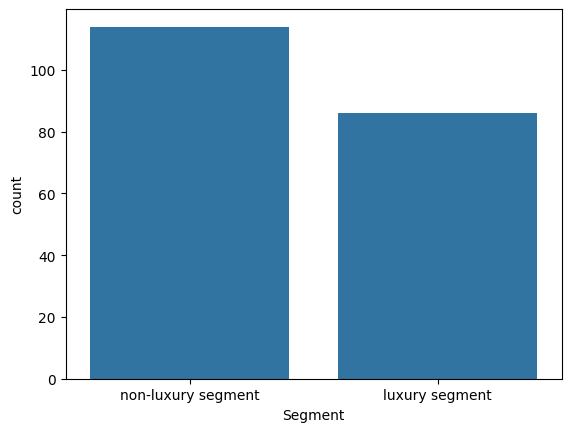

In [ ]:
# Visualize the distribution of vehicles across the luxury and non-luxury segments
sns.countplot(data=df_used_cars_cp, x='Segment');

**Observations**

The dataset contains two vehicle categories under the Segment feature — non-luxury segment (114 vehicles) and luxury segment (86 vehicles). The slight dominance of non-luxury vehicles suggests a moderately balanced distribution, allowing fair representation of both market segments for model training and comparison.

**Kilometers_Driven**

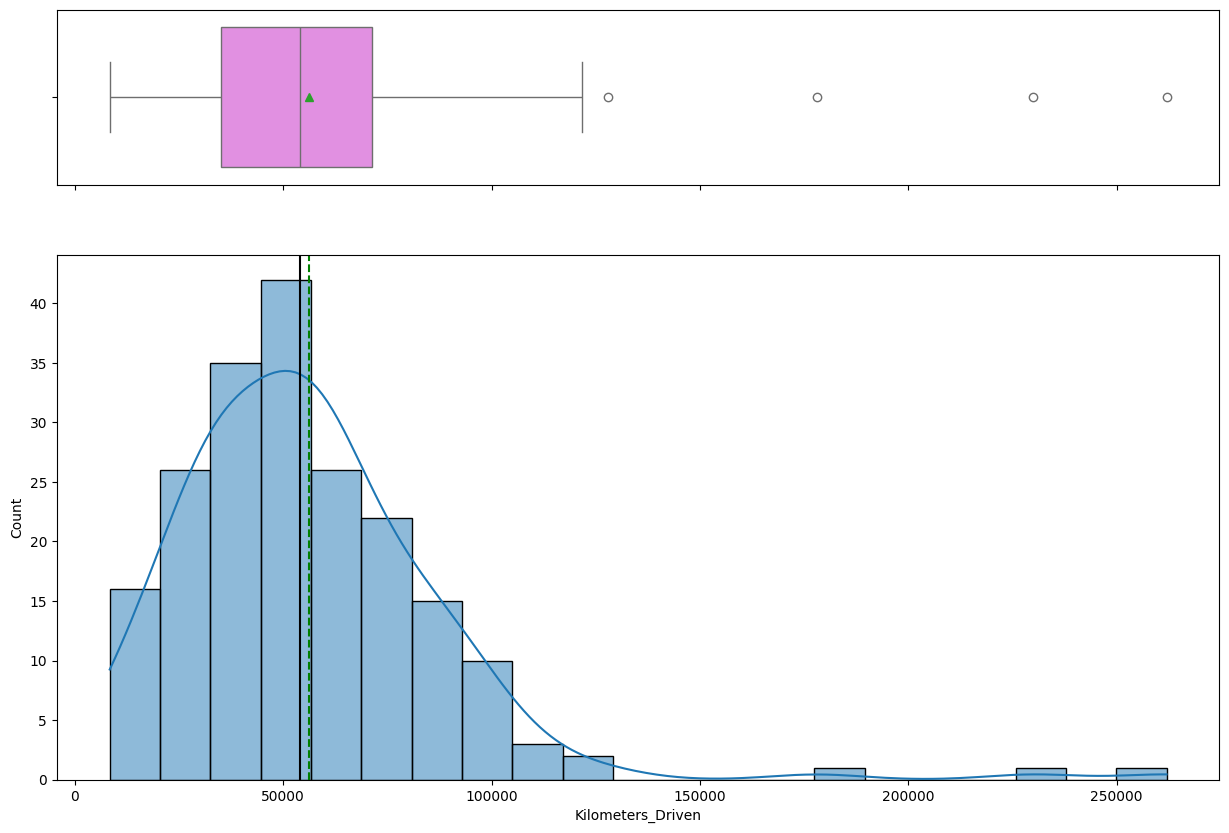

In [ ]:
# Visualize the distribution of kilometers driven
histogram_boxplot(df_used_cars_cp, "Kilometers_Driven", kde=True)


**Observations**

* The distribution of Kilometers_Driven is right-skewed, confirming the pattern observed in the statistical summary.

* Most vehicles have been driven between 30,000 and 80,000 km, representing the typical usage range.

* A few vehicles exceeding 150,000 km extend the right tail of the distribution.

* The boxplot identifies these high-mileage vehicles as potential outliers, which are likely genuine cases of older or heavily used cars.

**Mileage**

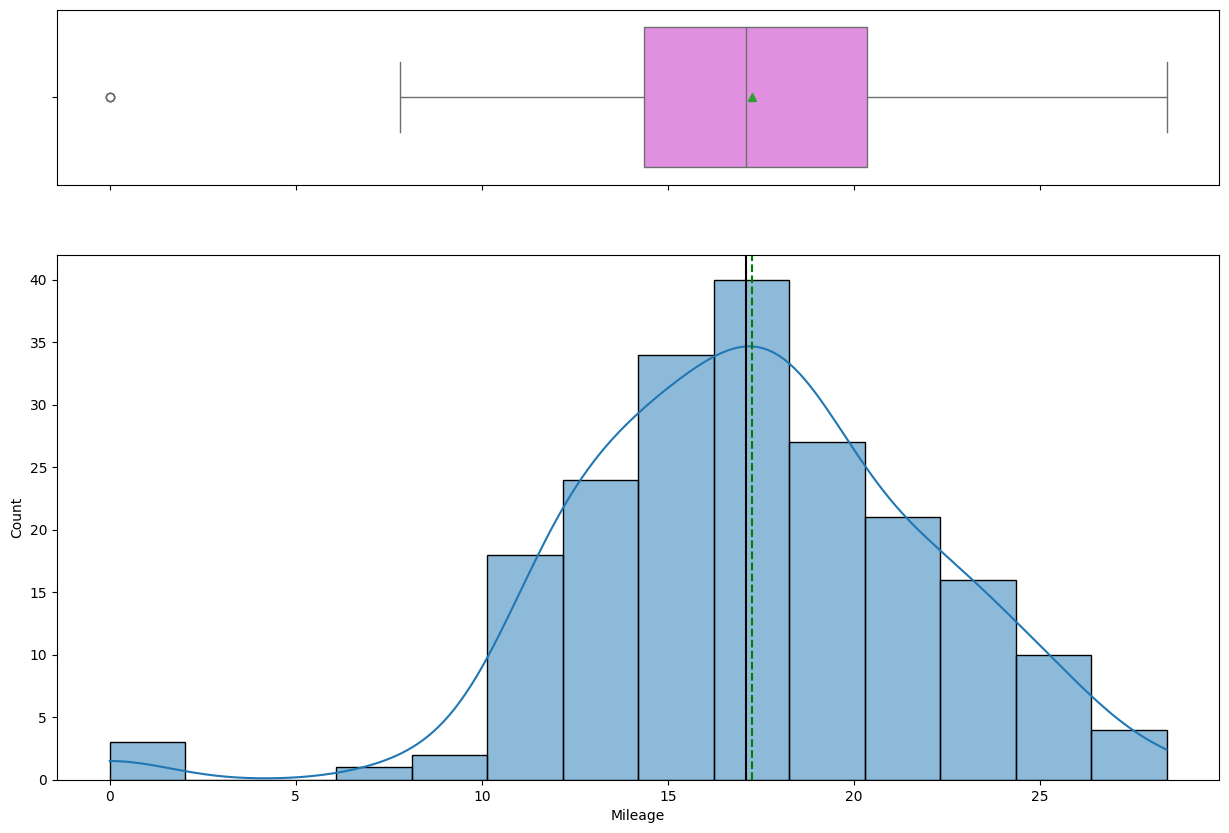

In [ ]:
# Visualize the distribution of Mileage
histogram_boxplot(df_used_cars_cp, "Mileage", kde=True)


**Observations**

* The distribution of Mileage appears approximately normal, with most vehicles having fuel efficiency between 12 km/l and 22 km/l.

* The mean and median are close, suggesting minimal skewness, though a slight left skew is present due to a few lower mileage values.

* The boxplot highlights one clear outlier around 0 km/l, which is unrealistic and likely represents an invalid or incorrectly recorded entry.

* This visualization provides clarity and confirms the earlier indication of slight left skewness observed in the statistical summary.

* Overall, the distribution shows consistent mileage values suitable for analysis after addressing the zero-value anomaly.

**Engine**

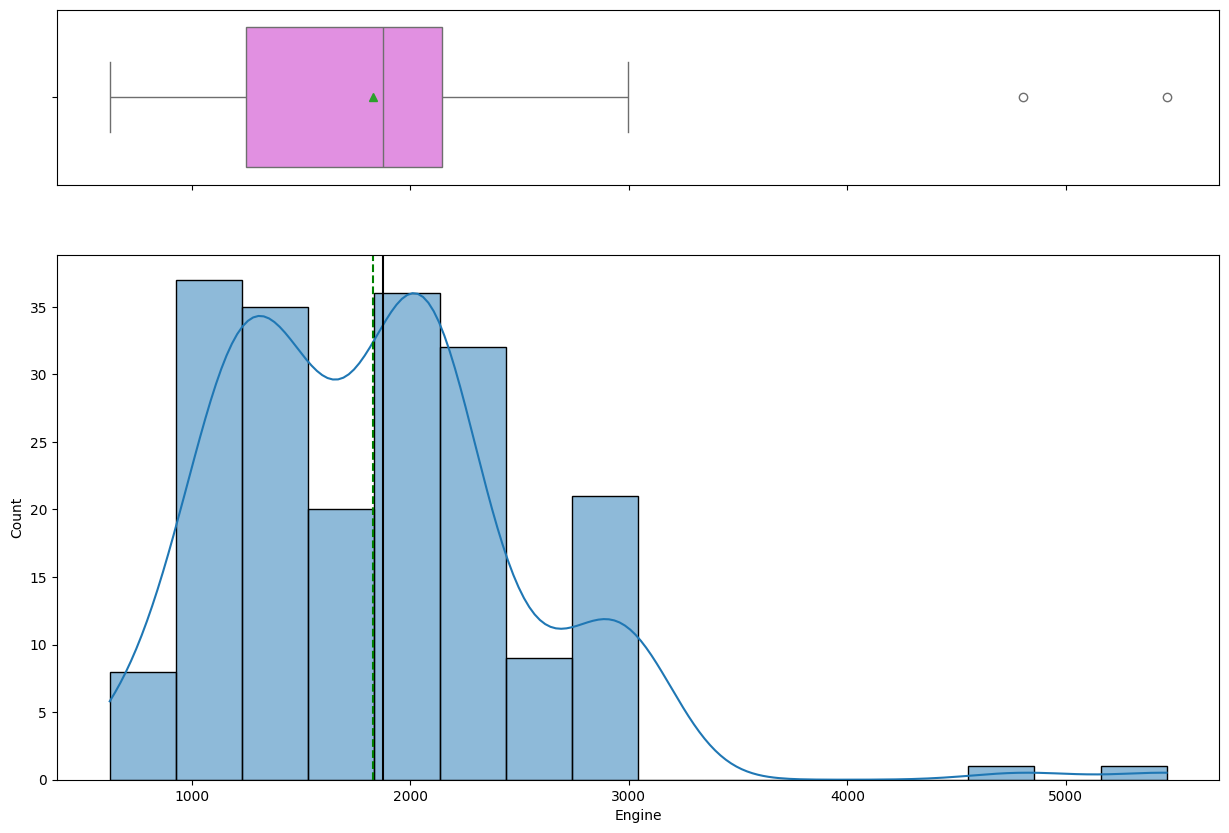

In [ ]:
# Visualize the distribution of Engine
histogram_boxplot(df_used_cars_cp, "Engine", kde=True)

**Observations**

* The distribution of Engine capacity is bimodal and right-skewed, with two distinct peaks around 1,200–1,400 cc and 1,800–2,000 cc, representing common engine sizes for different vehicle segments.

* Most vehicles fall between 1,000 cc and 2,500 cc, while a few with larger engines above 4,000 cc extend the right tail.

* The boxplot identifies these high-capacity engines as potential outliers, which likely correspond to high-performance or luxury vehicles rather than data errors.

* Overall, the distribution confirms potential right skewness and highlights segment-based variation in engine sizes across the dataset.

**Power**

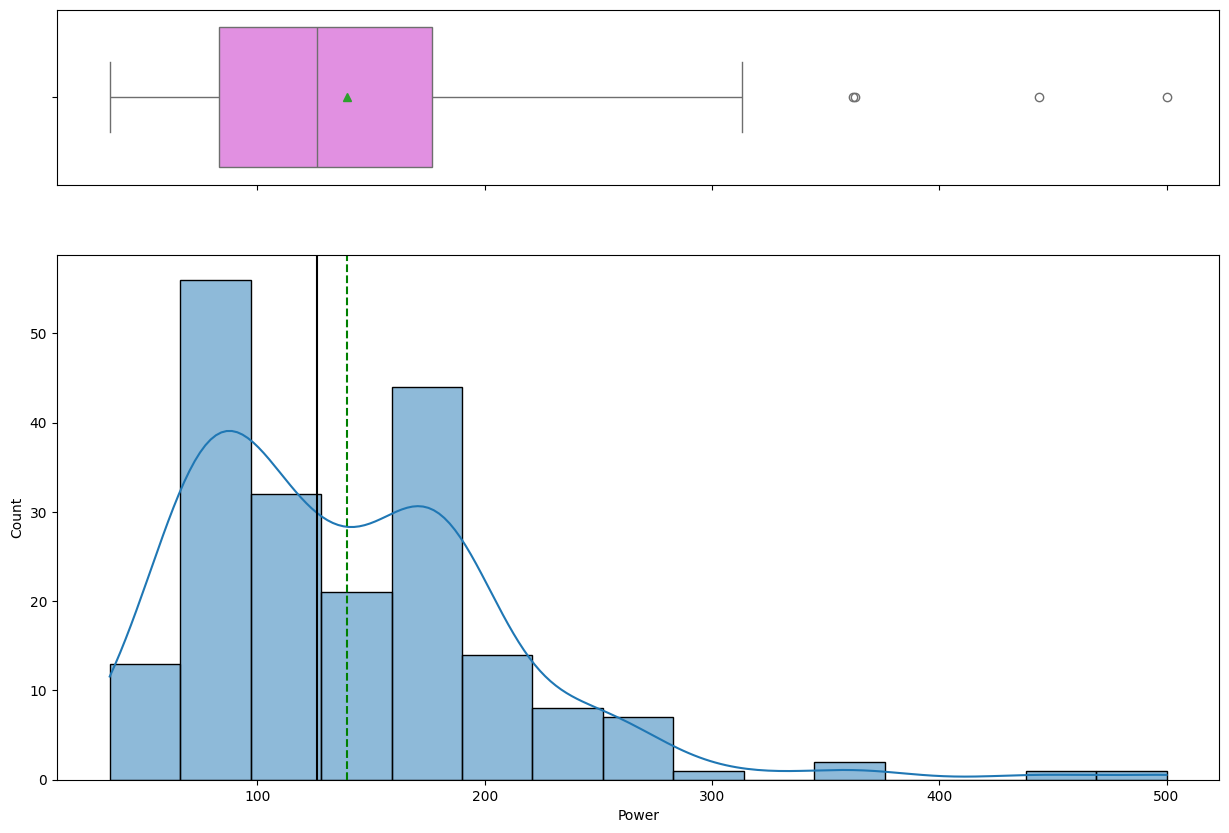

In [ ]:
# Visualize the distribution of Power
histogram_boxplot(df_used_cars_cp, "Power", kde=True)

**Observations**

* The distribution of Power is bimodal and right-skewed, with two visible peaks around 80–100 BHP and 150–180 BHP, representing lower-powered economy vehicles and higher-powered luxury or performance models.

* Most vehicles fall within the 80–200 BHP range, while a few outliers exceed 350 BHP, extending the right tail of the distribution.

* The boxplot confirms the presence of these high-power outliers, which are likely genuine entries corresponding to premium models rather than data errors.

* Overall, the distribution aligns with the statistical summary, confirming potential right skewness and highlighting distinct power groupings across vehicle segments.

**Price**

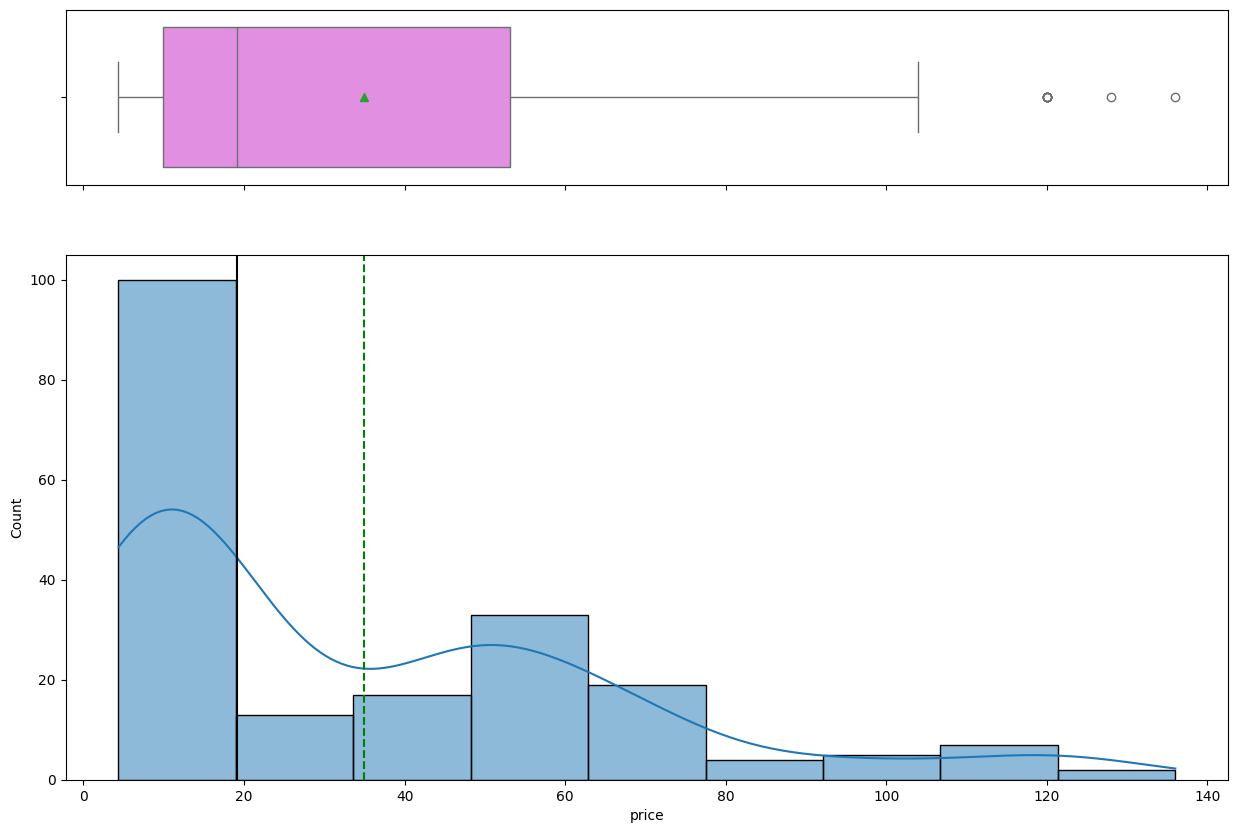

In [ ]:
# Visualize the distribution of Price
histogram_boxplot(df_used_cars_cp, "price", kde=True)

**Observations**

* The distribution of Price is right-skewed, showing that most vehicles fall at the lower end of the price range, while a few high-value cars extend the right tail.

* The majority of vehicles are priced below ₹40 lakh, indicating that lower-priced models dominate the dataset.

* The boxplot highlights several high-priced vehicles above ₹100 lakh as potential outliers, likely representing luxury or premium models rather than data errors.

* Overall, the distribution confirms potential right skewness, driven by the presence of a small number of high-end vehicles that raise the upper limit of the price range.

**Seats**

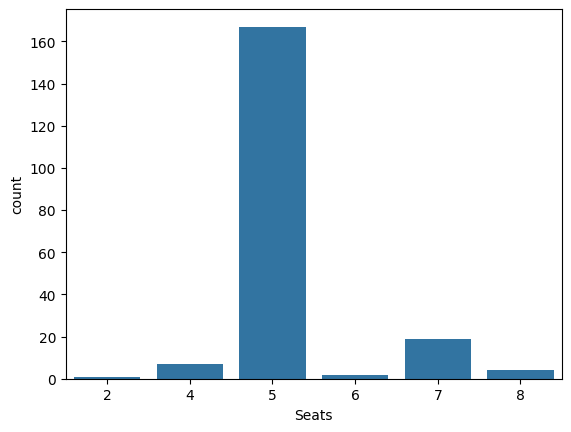

In [ ]:
# Visualize the distribution of vehicles based on seating capacity
sns.countplot(data=df_used_cars_cp, x='Seats');

**Observations**

* The majority of vehicles in the dataset have 5 seats, indicating that standard passenger cars dominate the collection.

* A smaller number of vehicles have 7 or 8 seats, likely representing SUVs or vans, while a few 2- and 4-seater cars correspond to sports or compact models.

* Overall, the distribution shows limited variation in seating capacity, with the 5-seater configuration being the most common and representative of the dataset.

### **2.3 Bivariate Analysis**

**Examine relationships between variables to understand how different features interact and influence vehicle pricing.**

**Correlation Check for numeric columns**

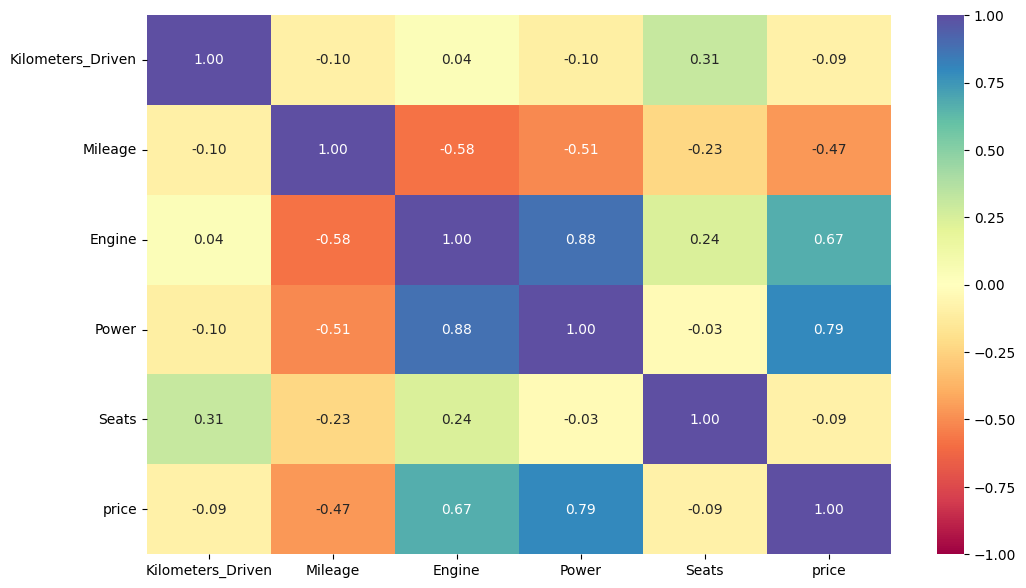

In [ ]:
# Select the numeric columns from the DataFrame and store their names in a list
cols_list = df_used_cars_cp.select_dtypes(include=np.number).columns.tolist()

# Set the figure size
plt.figure(figsize=(12, 7))

# Plot a heatmap to visualize the correlation matrix of the selected numeric columns
sns.heatmap(
    df_used_cars_cp[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)

# Display the heatmap
plt.show()

**Observations**

* Power shows the strongest positive correlation with Price (0.79), indicating that higher engine power is closely associated with higher vehicle prices.

* Engine capacity also has a moderate positive correlation (0.67) with Price, suggesting that vehicles with larger engines generally command higher prices.

* Mileage has a moderate negative correlation (-0.47) with Price, indicating that as fuel efficiency increases, vehicle prices tend to decrease. This suggests an inverse relationship between pricing and mileage performance, which can be further explored in relation to other influencing factors in subsequent analyses.

* Kilometers_Driven and Seats show very weak correlations with Price, suggesting that usage level and seating capacity have minimal direct impact on pricing compared to performance-related features.

**Price vs Segment**

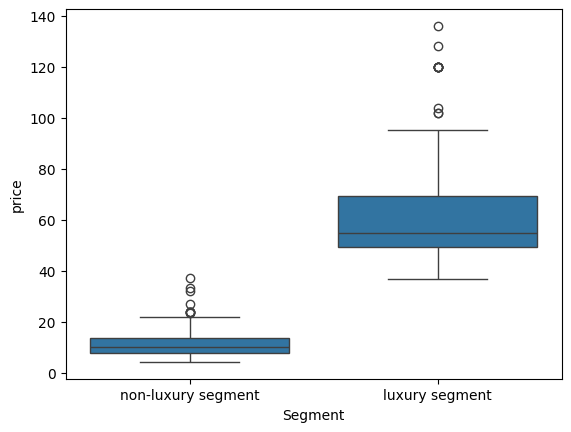

In [ ]:
# Boxplot of total price by time of day, with outliers displayed using showfliers=True
sns.boxplot(data=df_used_cars_cp, x='Segment',y='price',showfliers=True) # showfliers parameter controls the representation of outliers in the boxplot
plt.show()

**Observation**

* The boxplot shows a clear distinction in price distribution between the two vehicle segments.

* Luxury segment vehicles have significantly higher median prices and a wider range, indicating greater price variability within this group.

* Non-luxury segment vehicles cluster at the lower end of the price scale, with relatively fewer outliers and a smaller spread.

* The presence of multiple high-value outliers in the luxury segment reflects premium models that drive up the upper range of prices.

* Overall, the visualization confirms that vehicle segment is a strong differentiator of price, with luxury vehicles commanding substantially higher values.

### **2.3 Multivariate Analysis**

**Exploring all the variables to provide observations on their distributions.**

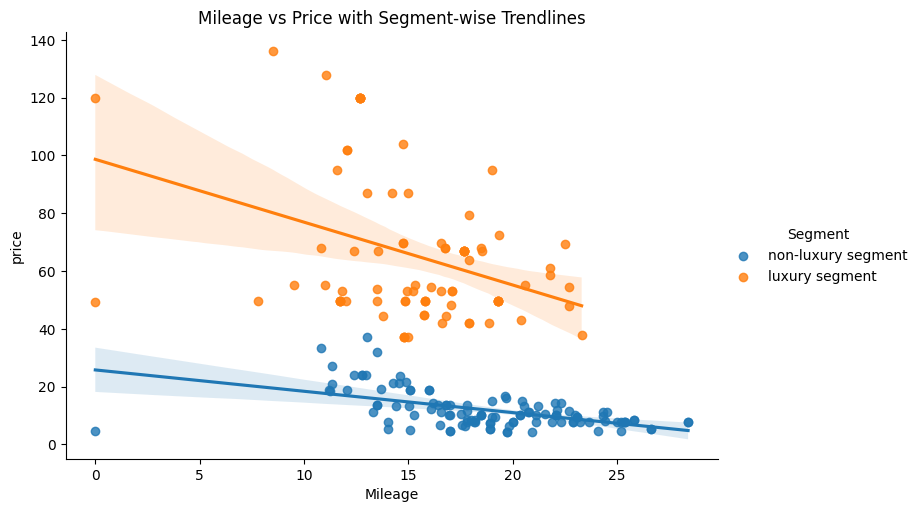

In [ ]:
# Regression lines for each segment
sns.lmplot(data=df_used_cars_cp, x='Mileage', y='price', hue='Segment', height=5, aspect=1.5)
plt.title('Mileage vs Price with Segment-wise Trendlines')
plt.show()

**Observations**

* The plot shows a negative relationship between Mileage and Price, indicating that vehicle prices tend to decrease as mileage increases.

* This downward trend is consistent across both luxury and non-luxury segments, suggesting that higher mileage leads to lower pricing irrespective of vehicle type.

* While luxury vehicles maintain higher overall prices, the impact of mileage on price depreciation appears similar across both categories.

* Overall, the relationship highlights that usage (mileage) is a key driver of price reduction, independent of the vehicle segment.

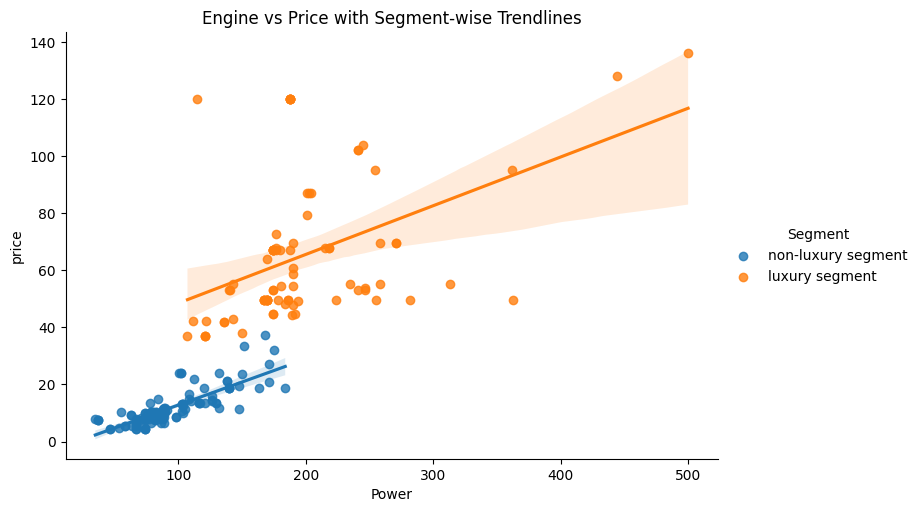

In [ ]:
# Regression lines for each segment
sns.lmplot(data=df_used_cars_cp, x='Power', y='price', hue='Segment', height=5, aspect=1.5)
plt.title('Engine vs Price with Segment-wise Trendlines')
plt.show()

**Observations**

* The plot reveals a clear positive relationship between Power and Price, where higher engine power corresponds to higher vehicle prices.

* This trend holds for both luxury and non-luxury segments, though the luxury vehicles occupy higher price and power ranges overall.

* The steeper slope for the luxury segment indicates that increases in power are associated with a more pronounced rise in price compared to non-luxury vehicles.

* Non-luxury vehicles exhibit a tighter cluster with smaller variation in price, suggesting limited pricing flexibility relative to performance.

* Overall, Power emerges as a strong differentiator of vehicle pricing, particularly evident within the luxury segment.

### **2.4 Insights based on EDA**

The **exploratory data analysis (EDA)** uncovers key patterns influencing vehicle pricing, performance characteristics, and segment differentiation. Below is a summary of the main findings:

 1. Data Quality: The dataset is clean with no missing or duplicate records. All values fall within logical ranges, aside from one unrealistic mileage entry (0 km/l), which can be treated as an anomaly.

 2. Vehicle Usage (Kilometers Driven): The distribution is right-skewed, with most vehicles driven between 30,000 and 70,000 km. A few higher readings above 150,000 km likely represent older or heavily used vehicles and should be retained as valid data points.

 3. Mileage: Displays an approximately normal distribution with most vehicles achieving 12–22 km/l. The 0 km/l entry is an outlier, but otherwise the data indicates a consistent efficiency range across the dataset.

 4. Engine & Power: Both attributes show right-skewed distributions with a few high-performance outliers (>4000 cc and >400 BHP). Power and Engine are highly correlated, confirming that performance characteristics increase proportionally and influence pricing.

 5. Seating Capacity: The majority of vehicles are 5-seaters, with limited variation across other capacities (2, 4, 7, or 8 seats), reflecting dominance of standard passenger configurations.

 6. Price: The distribution is right-skewed, with most vehicles priced below ₹40 lakh. A few high-value cars above ₹100 lakh represent premium or luxury models and align logically with market behavior.

 7. Segment Distribution: Non-luxury vehicles outnumber luxury models, suggesting a dataset weighted toward mass-market offerings.

 8. Price vs. Segment: Luxury vehicles exhibit substantially higher median prices and wider price variation, confirming segment-based pricing differentiation.

 9. Mileage vs. Price: A clear negative relationship exists — prices decrease as mileage increases. This pattern holds across both segments, indicating that vehicle usage drives depreciation regardless of category.

 10. Power vs. Price: Displays a strong positive relationship — higher engine power corresponds to higher prices. The relationship is more pronounced in the luxury segment, where increases in power are associated with greater price variation.

 11. Multivariate Observation: When considering Mileage, Power, and Segment together, price tends to decline with increased mileage and rise with greater power, showing that both performance and usage jointly shape vehicle valuation. The segment distinction amplifies these effects but does not alter their direction.

**Overall Story**: Vehicle pricing shows strong associations with performance (engine capacity and power) and usage (mileage), with segment classification further distinguishing price levels between luxury and non-luxury vehicles. Higher engine power and capacity correspond to higher prices, while increased mileage is linked to lower prices. The dataset is well-structured for modeling and reflects realistic market relationships among performance, usage, and pricing.


## **3. Model Development Workflow**

### **3.1 Data Preparation**

This **Data Preparation job** is designed to process an input dataset by splitting it into two parts: one for training the model and the other for testing it. The script accepts three inputs: the location of the input data (`used_cars.csv`), the ratio for splitting the data into training and testing sets (`test_train_ratio`), and the paths to save the resulting training (`train_data`) and testing (`test_data`) data. The script first reads the input CSV data from a data asset URI, then splits it using Scikit-learn's train_test_split function, and saves the two parts to the specified directories. It also logs the number of records in both the training and testing datasets using MLflow.

In [ ]:
# Create a directory for the preprocessing script
import os

src_dir_job_scripts = "./data_prep"
os.makedirs(src_dir_job_scripts, exist_ok=True)

In [ ]:
%%writefile {src_dir_job_scripts}/data_prep.py

import os
import argparse
import logging
import mlflow
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data", type=str, help="Path to input data")
    parser.add_argument("--test_train_ratio", type=float, default=0.2)
    parser.add_argument("--train_data", type=str, help="Path to save train data")
    parser.add_argument("--test_data", type=str, help="Path to save test data")
    args = parser.parse_args()

    # Start MLflow Run
    mlflow.start_run()

    # Log arguments
    logging.info(f"Input data path: {args.data}")
    logging.info(f"Test-train ratio: {args.test_train_ratio}")

    # Read data
    df = pd.read_csv(args.data)

    # Encoding the categorical 'Segment' column
    label_encoder = LabelEncoder()
    df['Segment'] = label_encoder.fit_transform(df['Segment'])

    # Log the first few rows of the dataframe
    logging.info(f"Transformed Data:\n{df.head()}")

    # Split data
    train_df, test_df = train_test_split(df, test_size=args.test_train_ratio, random_state=42)

    # Save train and test data
    os.makedirs(args.train_data, exist_ok=True)
    os.makedirs(args.test_data, exist_ok=True)
    train_df.to_csv(os.path.join(args.train_data, "data.csv"), index=False)
    test_df.to_csv(os.path.join(args.test_data, "data.csv"), index=False)

    # Log completion
    mlflow.log_metric("train_size", len(train_df))
    mlflow.log_metric("test_size", len(test_df))
    mlflow.end_run()

if __name__ == "__main__":
    main()

Overwriting ./data_prep/data_prep.py


#### **Define Data Preparation job**

For this AzureML job, we define the `command` object that takes input files and output directories, then executes the script with the provided inputs and outputs. The job runs in a pre-configured AzureML environment with the necessary libraries. The result will be two separate datasets for training and testing, ready for use in subsequent steps of the machine learning pipeline.

In [ ]:
from azure.ai.ml import command, Input, Output

step_process = command(
    name="data_preparation",
    display_name="Data preparation for training",
    description="Splits the input dataset into train and test datasets",
    inputs={
        "data": Input(type="uri_file"),
        "test_train_ratio": Input(type="number"),
    },
    outputs={
        "train_data": Output(type="uri_folder", mode="rw_mount"),
        "test_data": Output(type="uri_folder", mode="rw_mount"),
    },
    code="./data_prep",
    command="""python data_prep.py \
            --data ${{inputs.data}} \
            --test_train_ratio ${{inputs.test_train_ratio}} \
            --train_data ${{outputs.train_data}} \
            --test_data ${{outputs.test_data}}""",
    environment="AzureML-sklearn-1.0-ubuntu20.04-py38-cpu@latest",
)

### **3.2 Training the Model**

This Model Training job is designed to train a **Random Forest Regressor** on the dataset that was split into training and testing sets in the previous data preparation job. This job script accepts five inputs: the path to the training data (`train_data`), the path to the testing data (`test_data`), the number of trees in the forest (`n_estimators`, with a default value of 100), the maximum depth of the trees (`max_depth`, which is set to None by default), and the path to save the trained model (`model_output`).

The script begins by reading the training and testing data files, then processes the data to separate features (X) and target labels (y). A Random Forest Regressor model is initialized using the given n_estimators and max_depth, and it is trained using the training data. The model's performance is evaluated using the `Mean Squared Error (MSE)`. The MSE score is logged in MLflow. Finally, the trained model is saved and stored in the specified output location as an MLflow model. The job completes by logging the final MSE score and ending the MLflow run.


In [ ]:
# Create a directory for the preprocessing script
import os

src_dir_job_scripts = "./model_train"
os.makedirs(src_dir_job_scripts, exist_ok=True)

In [ ]:
%%writefile {src_dir_job_scripts}/model_train.py

# Required imports for training
import mlflow
import argparse
import numpy as np
import os
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

os.makedirs("./outputs", exist_ok=True)  # Create the "outputs" directory if it doesn't exist

def select_first_file(path):
    """Selects the first file in a folder, assuming there's only one file.
    Args:
        path (str): Path to the directory or file to choose.
    Returns:
        str: Full path of the selected file.
    """
    files = os.listdir(path)
    return os.path.join(path, files[0])

def main():
    parser = argparse.ArgumentParser("train")
    parser.add_argument("--train_data", type=str, help="Path to train dataset")
    parser.add_argument("--test_data", type=str, help="Path to test dataset")
    parser.add_argument("--model_output", type=str, help="Path of output model")
    parser.add_argument('--n_estimators', type=int, default=100,
                        help='The number of trees in the forest')
    parser.add_argument('--max_depth', type=int, default=None,
                        help='The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.')
    args = parser.parse_args()

    # Start the MLflow experiment run
    with mlflow.start_run():

        # Load datasets
        train_df = pd.read_csv(select_first_file(args.train_data))
        test_df = pd.read_csv(select_first_file(args.test_data))

        # Dropping the label column and assigning it to y_train
        y_train = train_df["price"].values  # 'price' is the target variable in this case study

        # Dropping the 'price' column from train_df to get the features and converting to array for model training
        X_train = train_df.drop("price", axis=1).values

        # Dropping the label column and assigning it to y_test
        y_test = test_df["price"].values  # 'price' is the target variable for testing

        # Dropping the 'price' column from test_df to get the features and converting to array for model testing
        X_test = test_df.drop("price", axis=1).values

        # Initialize and train a RandomForest Regressor
        rforest_model =RandomForestRegressor(n_estimators=args.n_estimators, max_depth=args.max_depth, random_state=42)
        rforest_model= rforest_model.fit(X_train, y_train)

        # Log model hyperparameters
        mlflow.log_param("model", "RandomForestRegressor")  # Provide the model name
        mlflow.log_param("n_estimators", args.n_estimators)
        mlflow.log_param("max_depth", args.max_depth)

        # Predict using the RandomForest Regressor on test data
        rforest_predictions = rforest_model.predict(X_test)  # Predict the test data

        # Mean Squared Error (MSE) measures the average squared difference between predicted and actual prices — lower is better.

        # Compute and log mean squared error for test data
        mse = mean_squared_error(y_test, rforest_predictions)
        print('Mean Squared Error of RandomForest Regressor on test set: {:.2f}'.format(mse))
        # Logging the mse as a metric
        mlflow.log_metric("MSE", float(mse))  # Log the MSE

        # Root Mean Squared Error (RMSE) represents the square root of MSE —
        # it indicates how much the predicted prices deviate, on average, from the actual prices.
        # Lower RMSE values indicate better model performance.

        # Compute and log RMSE for test data
        rmse = mean_squared_error(y_test, rforest_predictions, squared=False)
        print('Root Mean Squared Error (RMSE) of RandomForest Regressor on test set: {:.2f}'.format(rmse))
        # Logging the RMSE as a metric
        mlflow.log_metric("RMSE", float(rmse))  # Log the RMSE

        # Adjusted R-squared (Adjusted R²) accounts for the number of predictors in the model.
        # Unlike regular R², it penalizes the addition of irrelevant features and increases only
        # if new predictors improve the model more than would be expected by chance.
        # Higher Adjusted R² values indicate a better-fitting model after adjusting for model complexity.

        # Compute and log Adjusted R² for test data
        r2 = r2_score(y_test, rforest_predictions)
        n = len(y_test)
        p = X_test.shape[1]

        if n > p + 1:
            adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
        else:
            adj_r2 = float('nan')  # Safeguard against invalid denominator when n <= p + 1
            print("Warning: Adjusted R² undefined because number of samples ≤ number of predictors + 1.")

        print('Adjusted R-squared (Adjusted R²) of RandomForest Regressor on test set: {:.4f}'.format(adj_r2))
        # Logging the Adjusted R² as a metric
        mlflow.log_metric("Adjusted_R2", float(adj_r2))  # Log the Adjusted R²

        # --- Compute and save feature importances for later visualization ---
        # Get the feature (column) names from the training dataset
        feature_names = train_df.drop("price", axis=1).columns

        # Extract feature importances from the trained RandomForest model
        importances = rforest_model.feature_importances_

        # Sort feature indices in descending order of importance
        indices = np.argsort(importances)[::-1]  # descending once

        # Create a DataFrame pairing each feature with its importance value
        fi_df = pd.DataFrame({
                 "feature": feature_names[indices],
                 "importance": importances[indices]
                 })

        # Save the feature importances to the outputs folder
        fi_csv = "./outputs/feature_importances.csv"
        fi_df.to_csv(fi_csv, index=False)


       # Log the file to MLflow so it appears under the run’s artifacts in Azure ML
        mlflow.log_artifact(fi_csv)

        # Output the trained model
        mlflow.sklearn.save_model(rforest_model, args.model_output)

if __name__ == "__main__":
    main()

Overwriting ./model_train/model_train.py


#### **Define Model Training Job**

For this AzureML job, we define the `command` object that takes the paths to the training and testing data, the number of trees in the forest (`n_estimators`), and the maximum depth of the trees (`max_depth`) as inputs, and outputs the trained model. The command runs in a pre-configured AzureML environment with all the necessary libraries. The job produces a trained **Random Forest Regressor model**, which can be used for predicting the price of used cars based on the given attributes.

In [ ]:
from azure.ai.ml import command, Input, Output

train_step = command(
    name="train_used_cars_price_prediction_model",  # Specify the name of the command step for model training
    display_name="Train Random Forest Regressor for Used Car Price Prediction",  # Provide a descriptive display name
    description="Train a Random Forest Regressor to Predict Used Car Price",  # Description of the task to be performed
    inputs={  # Define inputs required for the training command
        "train_data": Input(type="uri_folder"),  # Specify input type for train data (e.g., file URI)
        "test_data": Input(type="uri_folder"),  # Specify input type for test data (e.g., file URI)
        "n_estimators": Input(type="number", default=100),  # Specify default value for number of estimators (trees in Random Forest)
        "max_depth": Input(type="number", default=5),  # Set default value for the maximum depth of the trees
    },
    outputs={  # Define the output of the training job
        "model_output": Output(type="mlflow_model"),  # Path to save the trained model
    },
    code="model_train/",  # Fill in the directory where the training script (model_train.py) is located
    command="""python model_train.py \
            --train_data ${{inputs.train_data}} \
            --test_data ${{inputs.test_data}} \
            --n_estimators ${{inputs.n_estimators}} \
            --max_depth ${{inputs.max_depth}} \
            --model_output ${{outputs.model_output}}""",
    environment="AzureML-sklearn-1.0-ubuntu20.04-py38-cpu@latest",
    compute="cpu-cluster",  # Specify the compute target (e.g., "cpu-cluster")
)

### **3.3 Registering the Best Trained Model**

The **Model Registration job** is designed to take the best-trained model from the hyperparameter tuning sweep job and register it in MLflow as a versioned artifact for future use in the used car price prediction pipeline. This job script accepts one input: the path to the trained model (model). The script begins by loading the model using the `mlflow.sklearn.load_model()` function. Afterward, it registers the model in the MLflow model registry, assigning it a descriptive name (`used_cars_price_prediction_model`) and specifying an artifact path (`random_forest_price_regressor`) where the model artifacts will be stored. Using MLflow's `log_model()` function, the model is logged along with its metadata, ensuring that the model is easily trackable and retrievable for future evaluation, deployment, or retraining.

In [ ]:
# Create a directory for the preprocessing script
import os

src_dir_job_scripts = "./model_register"
os.makedirs(src_dir_job_scripts, exist_ok=True)

In [ ]:
%%writefile {src_dir_job_scripts}/model_register.py

import os
import argparse
import logging
import mlflow
import pandas as pd
from pathlib import Path

mlflow.start_run()  # Starting the MLflow experiment run

def main():
    # Argument parser setup for command line arguments
    parser = argparse.ArgumentParser()
    parser.add_argument("--model", type=str, help="Path to the trained model")  # Path to the trained model artifact
    args = parser.parse_args()

    # Load the trained model from the provided path
    model = mlflow.sklearn.load_model(Path(args.model))

    print("Registering the best trained used cars price prediction model")

    # Register the model in the MLflow Model Registry under the name "used_cars_pricing_prediction_model"
    mlflow.sklearn.log_model(
        sk_model=model,
        registered_model_name="used_cars_pricing_prediction_model",  # Descriptive model name for registration
        artifact_path="Random_forest_used_cars_pricing_prediction"  # Path to store model artifacts
    )

    # End the MLflow run
    mlflow.end_run()

if __name__ == "__main__":
    main()

Overwriting ./model_register/model_register.py


#### **Define Model Register Job**

For this AzureML job, a `command` object is defined to execute the `model_register.py` script. It accepts the best-trained model as input, runs the script in the `AzureML-sklearn-1.0-ubuntu20.04-py38-cpu` environment, and uses the same compute cluster as the previous jobs (`cpu-cluster`). This job plays a crucial role in the pipeline by ensuring that the best-performing model identified during hyperparameter tuning is systematically stored and made available in the MLflow registry for further evaluation, deployment, or retraining. Integrating this job into the end-to-end pipeline automates the process of registering high-quality models, completing the model development lifecycle and enabling the prediction of used car prices.

In [ ]:
from azure.ai.ml import command, Input

model_register_component = command(
    name="register_model",  # Name of the command step for predictions
    display_name="Register Model",  # Display name for the step
    description="Use the best trained model from previous job to register it as a model in MLflow",  # Description
    inputs={  # Inputs required for the command
        "model": Input(type="mlflow_model"),  # Path to the best trained model
    },
    code="model_register/",  # Directory where the prediction script is located
    command="""python model_register.py \
            --model ${{inputs.model}}""",  # Command to run the prediction script
    environment="AzureML-sklearn-1.0-ubuntu20.04-py38-cpu@latest",  # Environment configuration for the prediction job
    compute="cpu-cluster",  # Specify the compute target to be used for the job
)

### **3.4. Assembling the End-to-End Workflow**

The end-to-end pipeline integrates all the previously defined jobs into a seamless workflow, automating the process of data preparation, model training, hyperparameter tuning, and model registration. The pipeline is designed using Azure Machine Learning's `@pipeline` decorator, specifying the compute target and providing a detailed description of the workflow.

In [ ]:
from azure.ai.ml.sweep import Choice
from azure.ai.ml.entities import Model
from azure.ai.ml.constants import ModelType
from azure.ai.ml.dsl import pipeline

# Assemble the pipeline by chaining the jobs
@pipeline(
    compute="cpu-cluster",  # Compute target for the pipeline
    description="Pipeline for data preparation, training, prediction, and model registration",  # Provide a description for the pipeline
)
def complete_pipeline_azuremls(input_data_uri, test_train_ratio, n_estimators, max_depth):

    # Step 1: Preprocess the data
    preprocess_step = step_process(
        data=input_data_uri,  # Input URI for data
        test_train_ratio=test_train_ratio,  # Input for the train-test split ratio (e.g., 0.8)
    )

    # Step 2: Train the model using preprocessed data
    training_step = train_step(
        train_data=preprocess_step.outputs.train_data,  # Output from data preprocessing (training data)
        test_data=preprocess_step.outputs.test_data,  # Output from data preprocessing (testing data)
        n_estimators=n_estimators,  # Input for the number of estimators (e.g., 50)
        max_depth=max_depth  # Input for the maximum depth of trees (e.g., 10)
    )

    # Define the training step with hyperparameters for tuning
    train_for_sweep = training_step(
        train_data=preprocess_step.outputs.train_data,
        test_data=preprocess_step.outputs.test_data,
        n_estimators=Choice(values=[10, 20, 30, 50]),
        # use -1 to represent "no limit"; handle in script (see note below)
        max_depth=Choice(values=[3, 5, 10]),
    )

    # Define the sweep job
    sweep_job = train_for_sweep.sweep(
        compute="cpu-cluster",
        sampling_algorithm="random",
        primary_metric="MSE",
        goal="Minimize",
    )

    """
    # Step 2: Train the model using preprocessed data
    training_step = train_step(
        train_data=preprocess_step.outputs.train_data,  # Output from data preprocessing (training data)
        test_data=preprocess_step.outputs.test_data,  # Output from data preprocessing (testing data)
        n_estimators=n_estimators,  # Input for the number of estimators (e.g., 50)
        max_depth=max_depth  # Input for the maximum depth of trees (e.g., 10)
    )

    """
    """
    # Define the training step with hyperparameters for tuning
    job_for_sweep = training_step(
        n_estimators=Choice(values=[10, 20, 30, 50]),
        max_depth=Choice(values=[3, 5, 10, None]),  # List of possible values for max_depth
    )


    # Define the sweep job
    sweep_job = job_for_sweep.sweep(
        compute="cpu-cluster",
        sampling_algorithm="random",
        primary_metric="MSE",
        goal="Minimize",
    )
    """
    # Set the limits for the sweep job:
    # - max_total_trials: The maximum number of hyperparameter combinations to be evaluated (20 in this case).
    # - max_concurrent_trials: The maximum number of trials to run simultaneously (10 in this case) to optimize resource utilization.
    # - timeout: The maximum allowed duration for the sweep job in seconds (7200 seconds, or 2 hours).
    sweep_job.set_limits(max_total_trials=20, max_concurrent_trials=10, timeout=7200)

    # Step 3: Register the best model
    # After the sweep job, get the best model
    model_register_step = model_register_component(
        model=sweep_job.outputs.model_output,  # Best model from sweep job
    )

    # Returning outputs from all steps in the pipeline
    return {
        "pipeline_job_train_data": preprocess_step.outputs.train_data,  # Output from preprocessing step (train data)
        "pipeline_job_test_data": preprocess_step.outputs.test_data,  # Output from preprocessing step (test data)
        "pipeline_job_best_model": sweep_job.outputs.model_output,  # Output from sweep job (best model)
    }


1. **Data Preparation (Preprocessing Step)**:
The pipeline starts by invoking the `step_process` job, which preprocesses the raw input data (`input_data_uri`). This step splits the dataset into training and testing sets based on the provided `test_train_ratio`. The outputs from this step include the processed training and testing datasets (`train_data` and `test_data`), which are passed as inputs to the next step.

2. **Model Training**:
The second step in the pipeline is the `train_step`, which trains a **Random Forest Regressor model** using the preprocessed training data. The job uses `train_data` and `test_data` from the preprocessing step and accepts hyperparameters like `n_estimators` and `max_depth` to configure the model. The training step is designed to work flexibly with the parameters defined in the pipeline, allowing experimentation. This step evaluates the model's performance using the `Mean Squared Error (MSE)` metric and logs the result in MLflow. The trained model is then saved and stored in the specified output location as an MLflow model.

3. **Hyperparameter Tuning**:
To optimize the model's performance, a Sweep Job is defined based on the training step. The sweep job explores multiple combinations of hyperparameters (`n_estimators` and `max_depth`) using a random sampling algorithm. It aims to minimize the model's `Mean Squared Error (MSE)` to ensure accurate price predictions. The job limits are set to allow a maximum of 20 trials, with up to 10 trials running concurrently, and a total timeout of 7200 seconds (2 hours). This step identifies the best combination of hyperparameters for the model.

4. **Model Registration**:
Once the sweep job completes, the best-performing model is passed to the `model_register_component`. This step registers the model in the MLflow model registry, ensuring that it is versioned and available for deployment or future experimentation. The registered model includes its metadata and is stored with a descriptive name (`used_cars_pricing_prediction_model`).

5. **Pipeline Outputs**:
The pipeline returns key outputs for further analysis, including the locations of the training and testing datasets and the best-trained model from the sweep job. These outputs ensure traceability and provide resources for subsequent tasks like evaluation and deployment.

In [ ]:
# The code retrieves a specific version of a registered data asset using the ml_client object.
data_path = ml_client.data.get("used-cars-data", version="1").path

In [ ]:
# Create pipeline instance
pipeline_instance = complete_pipeline_azuremls(
    input_data_uri=Input(type="uri_file", path=data_path),  # Dataset path
    test_train_ratio=0.2,  # Test-train ratio
    n_estimators=50,       # Initial value for n_estimators
    max_depth=5             # Initial value for max depth
)

In [ ]:
# Submit the pipeline to Azure ML
pipeline_job = ml_client.jobs.create_or_update(
    pipeline_instance,
    experiment_name="random_forest_training_pipeline_azuremls" # Provide the experiment name
)

# Stream the output of the job for real-time logs
ml_client.jobs.stream(pipeline_job.name)

pathOnCompute is not a known attribute of class <class 'azure.ai.ml._restclient.v2023_04_01_preview.models._models_py3.MLFlowModelJobOutput'> and will be ignored
pathOnCompute is not a known attribute of class <class 'azure.ai.ml._restclient.v2023_04_01_preview.models._models_py3.UriFolderJobOutput'> and will be ignored
pathOnCompute is not a known attribute of class <class 'azure.ai.ml._restclient.v2023_04_01_preview.models._models_py3.UriFolderJobOutput'> and will be ignored
pathOnCompute is not a known attribute of class <class 'azure.ai.ml._restclient.v2023_04_01_preview.models._models_py3.MLFlowModelJobOutput'> and will be ignored


RunId: silly_car_lk4w26b7lr
Web View: https://ml.azure.com/runs/silly_car_lk4w26b7lr?wsid=/subscriptions/a41098da-93d1-486e-86af-6e151bb41716/resourcegroups/gl_resource_grp/workspaces/FitwellWorkspace

Streaming logs/azureml/executionlogs.txt

[2025-11-03 21:44:24Z] Completing processing run id 3be0608d-0d4e-4ab6-a287-48972d471e28.
[2025-11-03 21:44:25Z] Completing processing run id 99010b55-1f64-46bc-9ccb-41151101c81c.
[2025-11-03 21:44:26Z] Submitting 1 runs, first five are: 1fb2159e:1eaf9f76-2e58-4263-96a6-fb4a378ab986
[2025-11-03 21:56:47Z] Completing processing run id 1eaf9f76-2e58-4263-96a6-fb4a378ab986.
[2025-11-03 21:56:48Z] Submitting 1 runs, first five are: 0dbe69a0:a3521ca8-3d6c-487c-90c1-958ce09d985a
[2025-11-03 21:57:36Z] Completing processing run id a3521ca8-3d6c-487c-90c1-958ce09d985a.

Execution Summary
RunId: silly_car_lk4w26b7lr
Web View: https://ml.azure.com/runs/silly_car_lk4w26b7lr?wsid=/subscriptions/a41098da-93d1-486e-86af-6e151bb41716/resourcegroups/gl_resource_

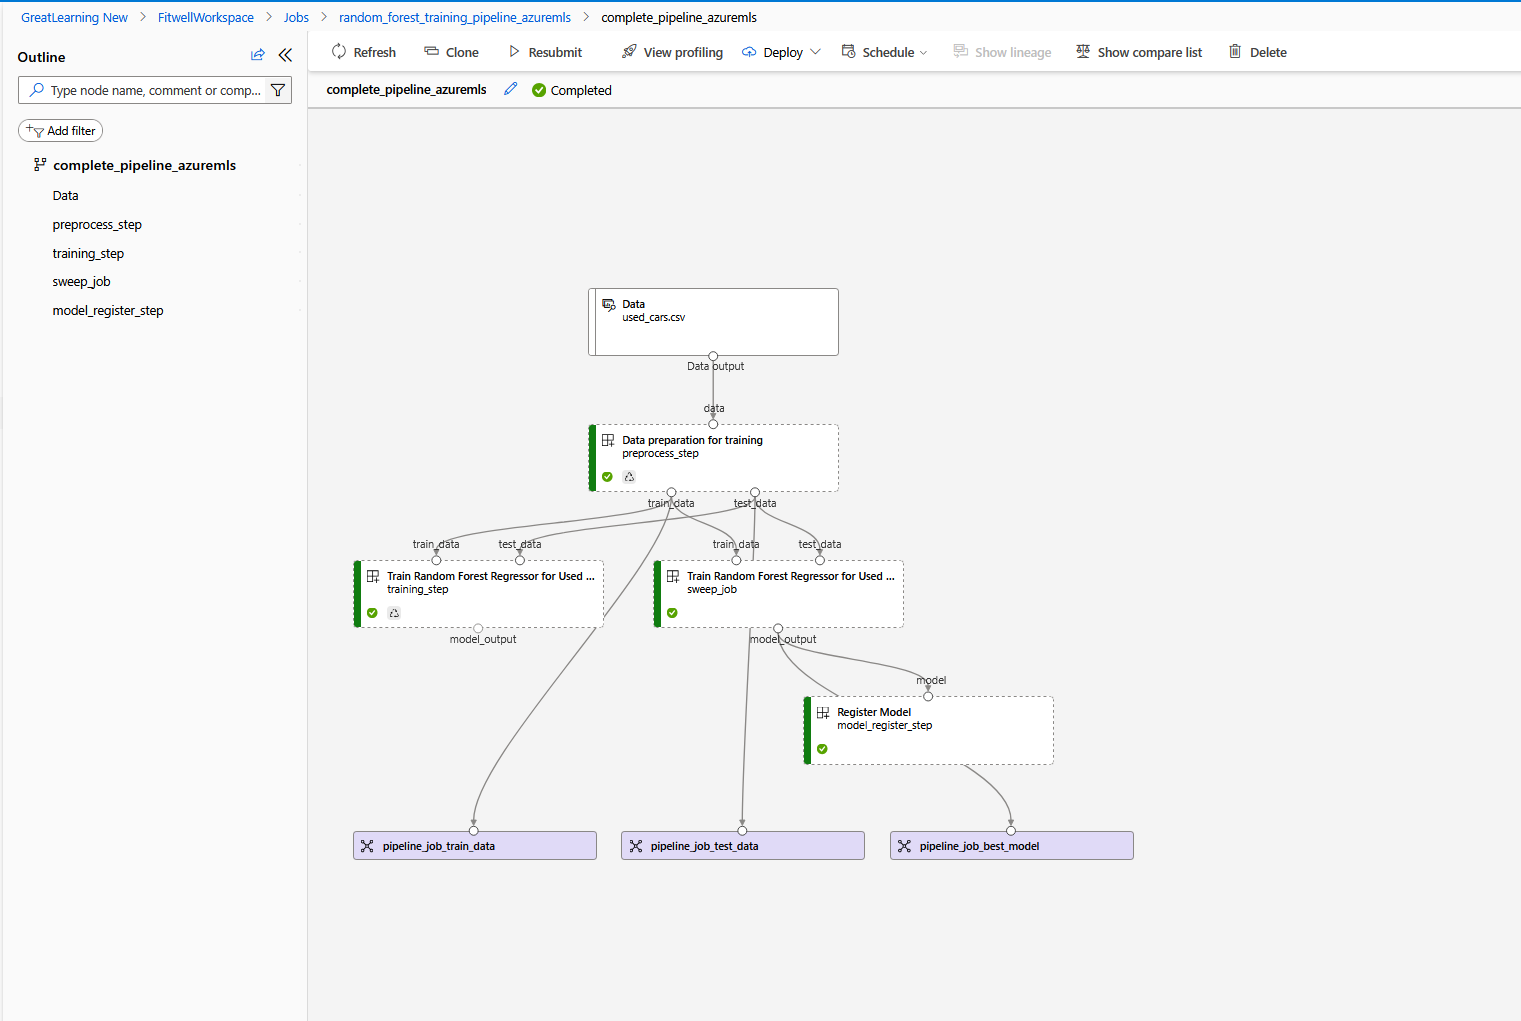

In [ ]:
from IPython import display
display.Image("artifacts/images/PipelineArchitecture.png")

## **4. Model Evaluation**

### **4.1 Best Model Run – Artifacts and Metrics**

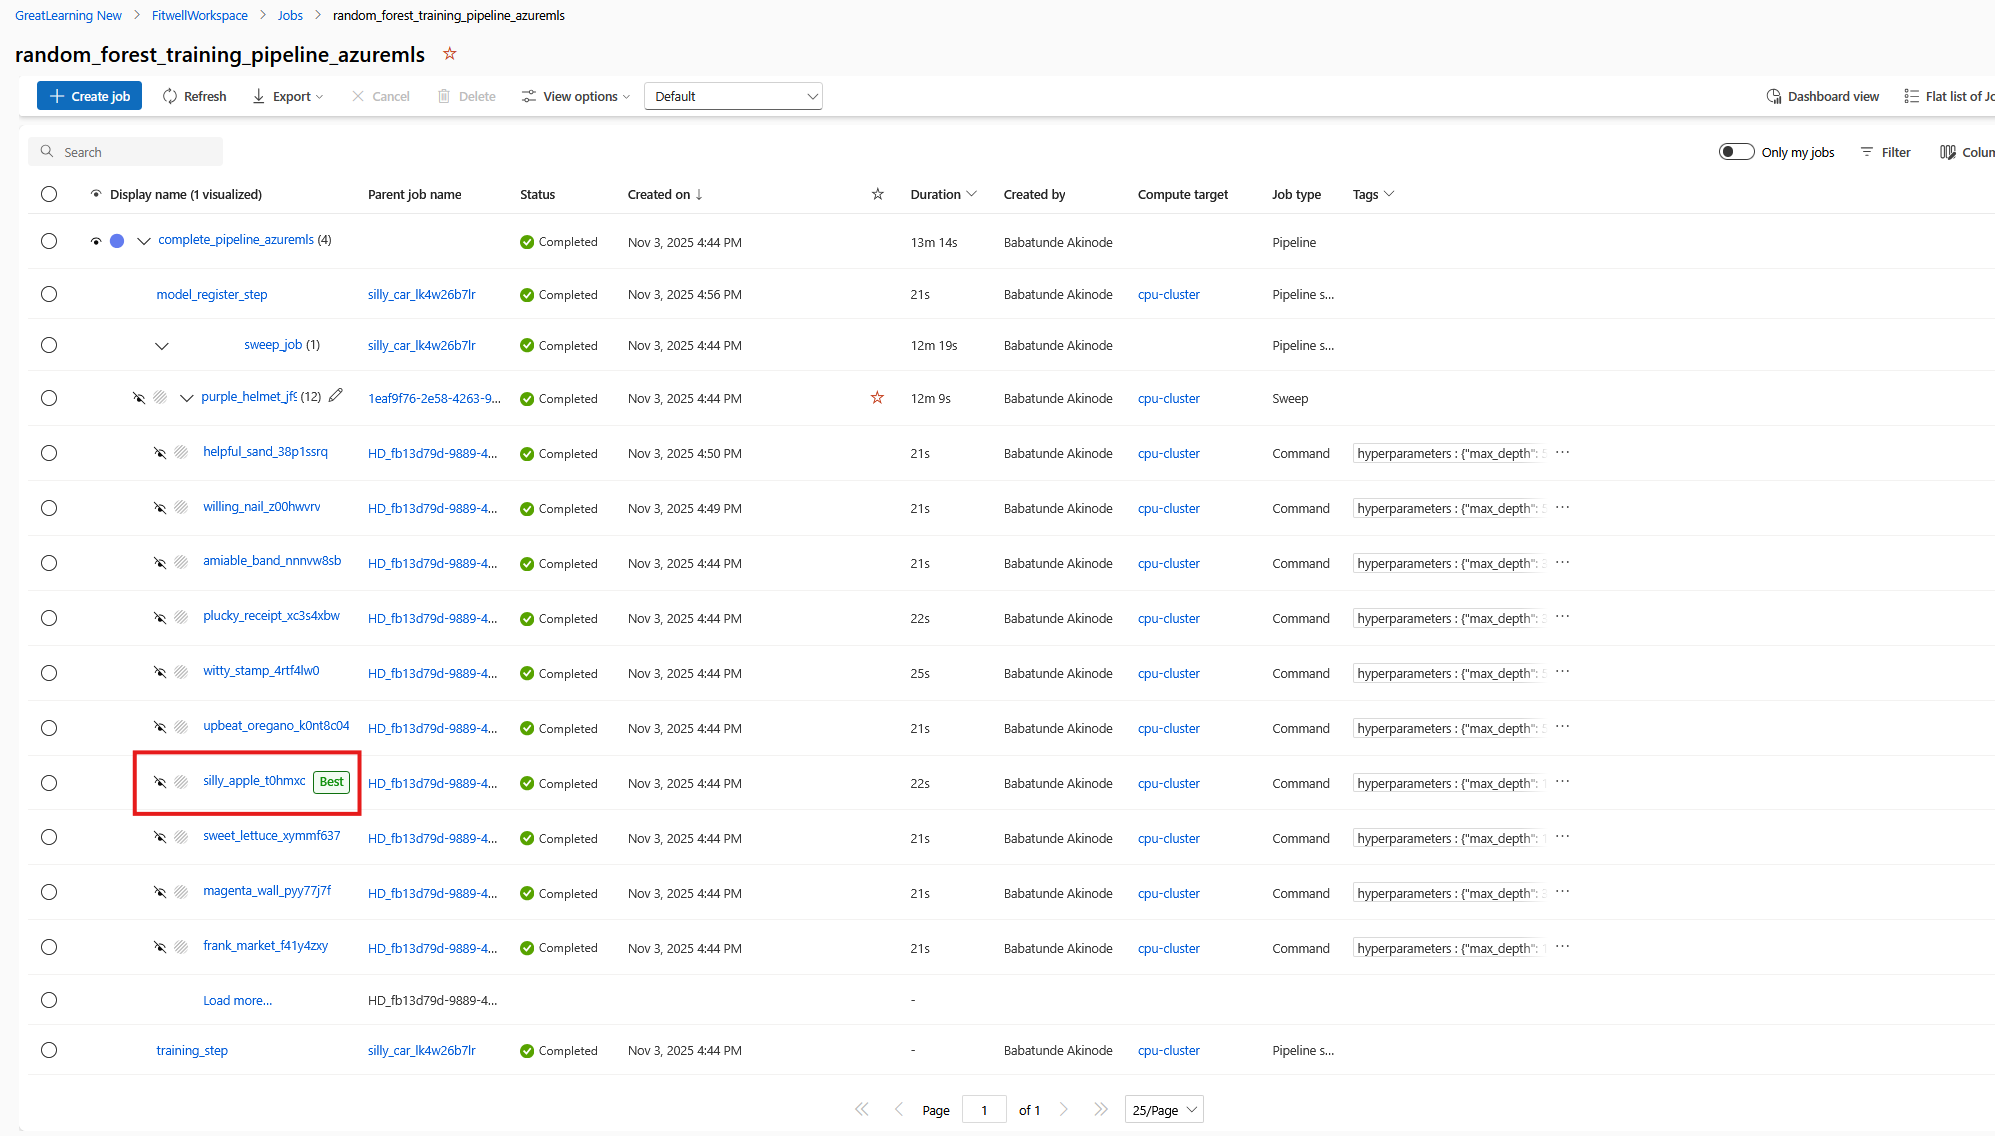

In [ ]:
from IPython import display
display.Image("artifacts/images/BestModel_.png")

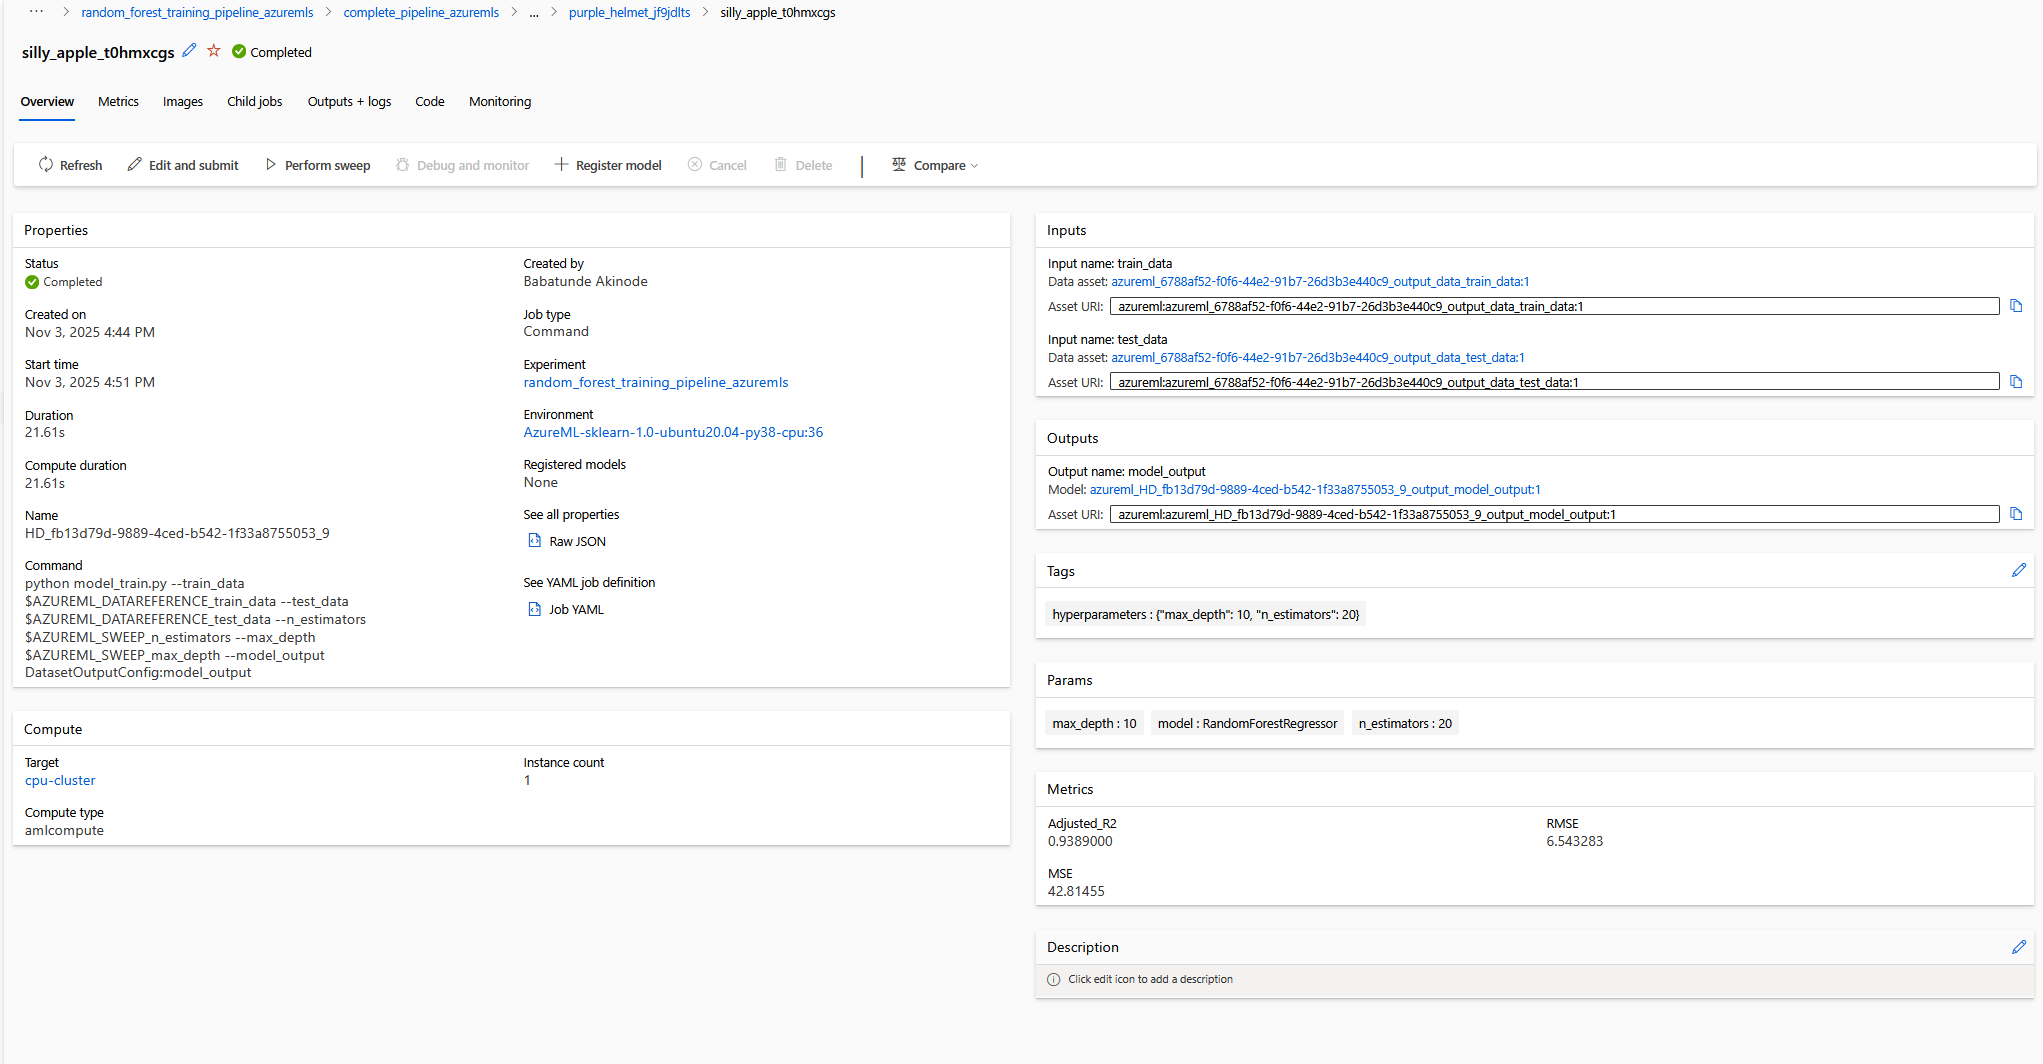

In [ ]:
from IPython import display
display.Image("artifacts/images/BestModel_Overview.png")

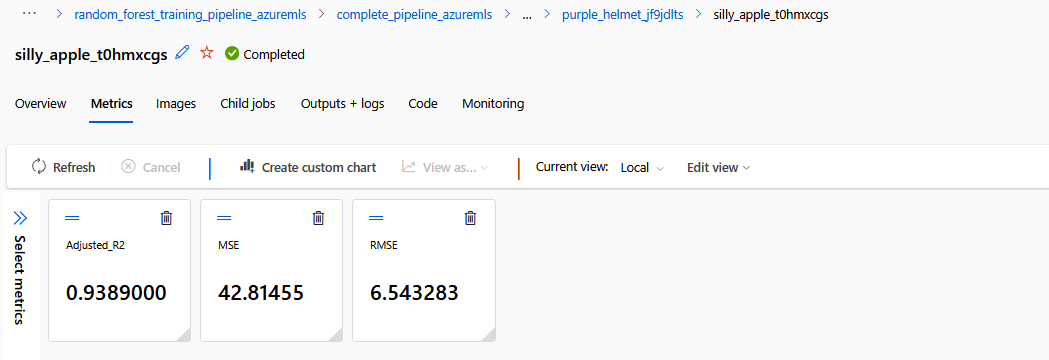

In [ ]:
from IPython import display
display.Image("artifacts/images/BestModel__Metric.png")

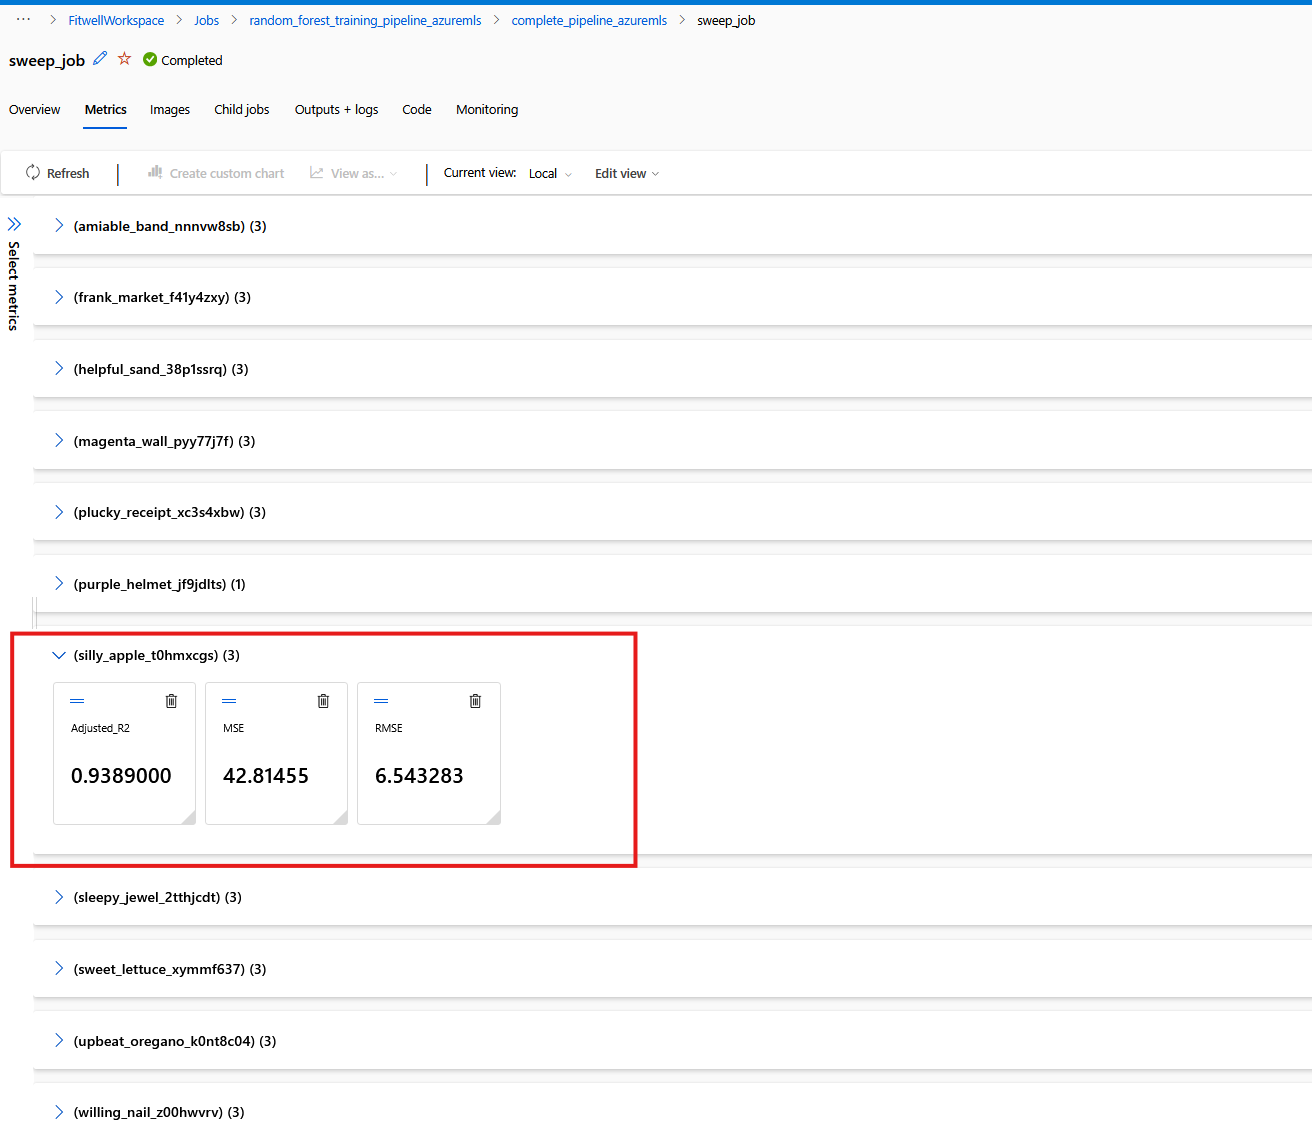

In [ ]:
from IPython import display
display.Image("artifacts/images/BestModel__Metric_Sweepjob.png")

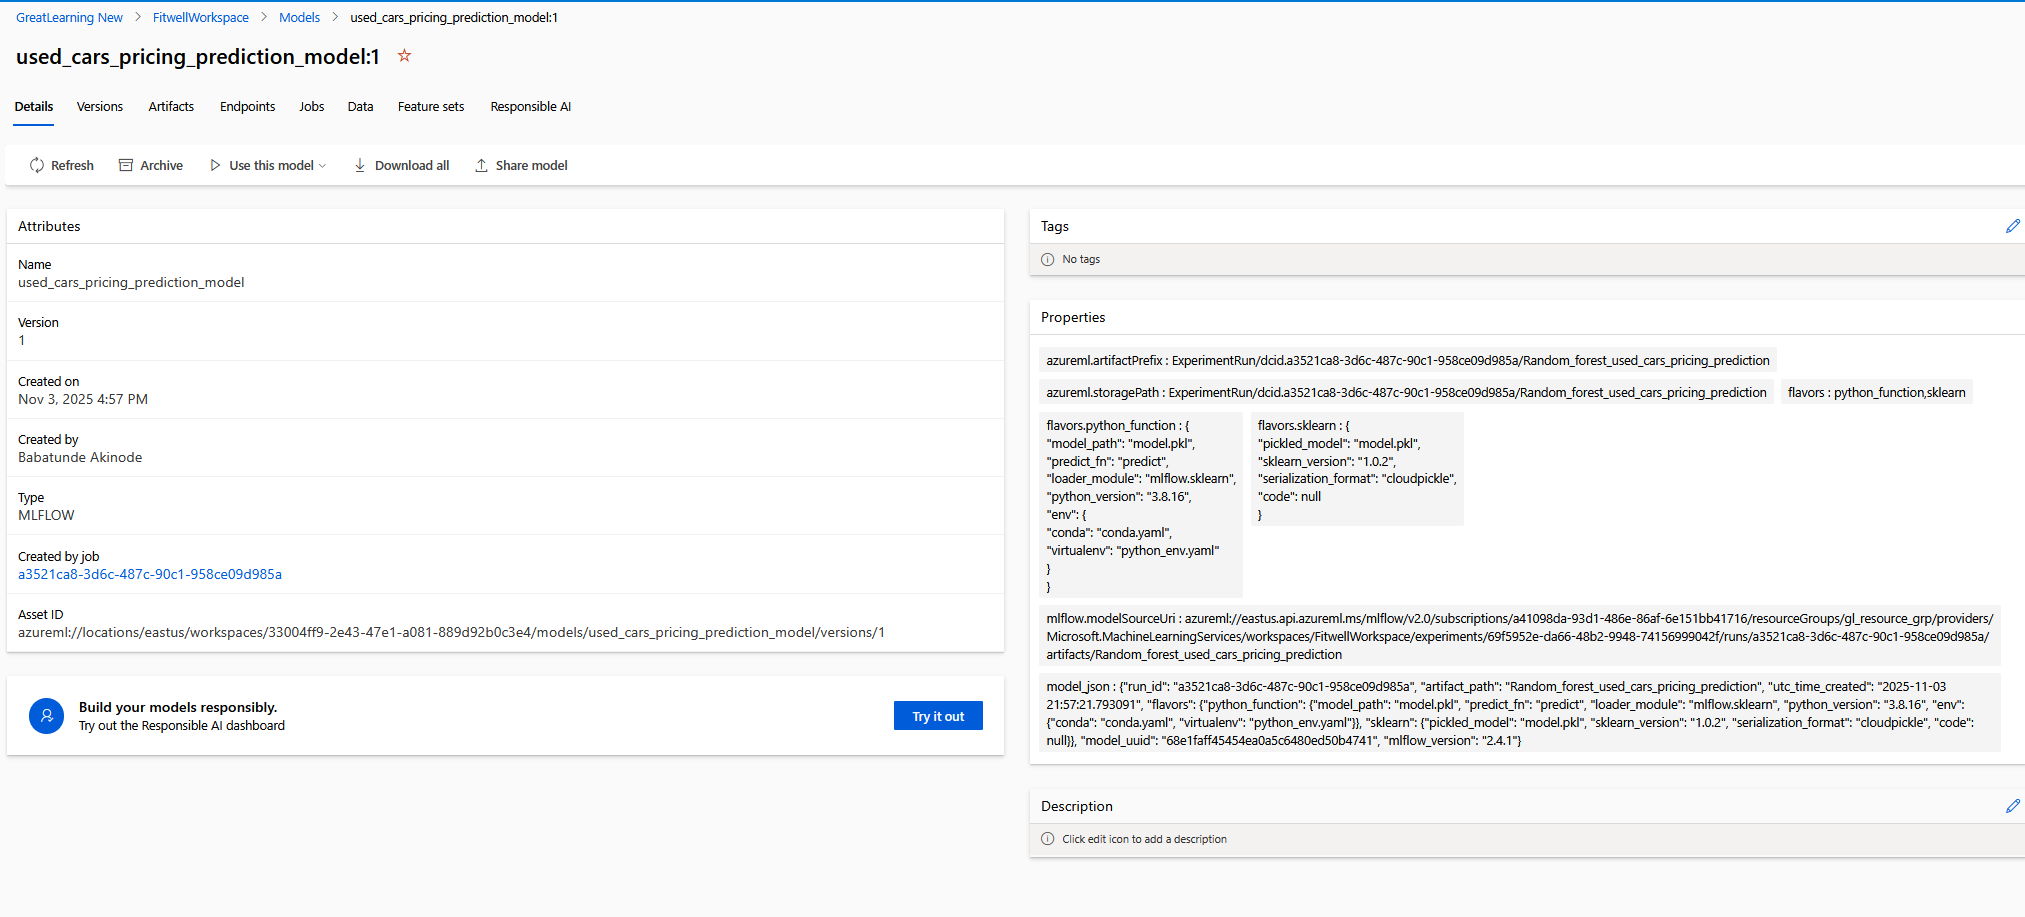

In [ ]:
from IPython import display
display.Image("artifacts/images/RegisteredModel.png")

### **4.2 Visualize Feature Importance**

In [ ]:
# List child jobs and pick the one with display_name 'train_step'
children = list(ml_client.jobs.list(parent_job_name=pipeline_job.name))
train_step_job = [j for j in children if j.display_name == "training_step"][0]

# Download all artifacts generated from the training job to the specified local directory
ml_client.jobs.download(
    name=train_step_job.name,
    download_path="artifacts/training_step",
    all=True
)

job 99010b55-1f64-46bc-9ccb-41151101c81c reuses previous job ec555652-9d96-4231-99d7-935aaa2c4142, download from the reused job.


Matplotlib is building the font cache; this may take a moment.


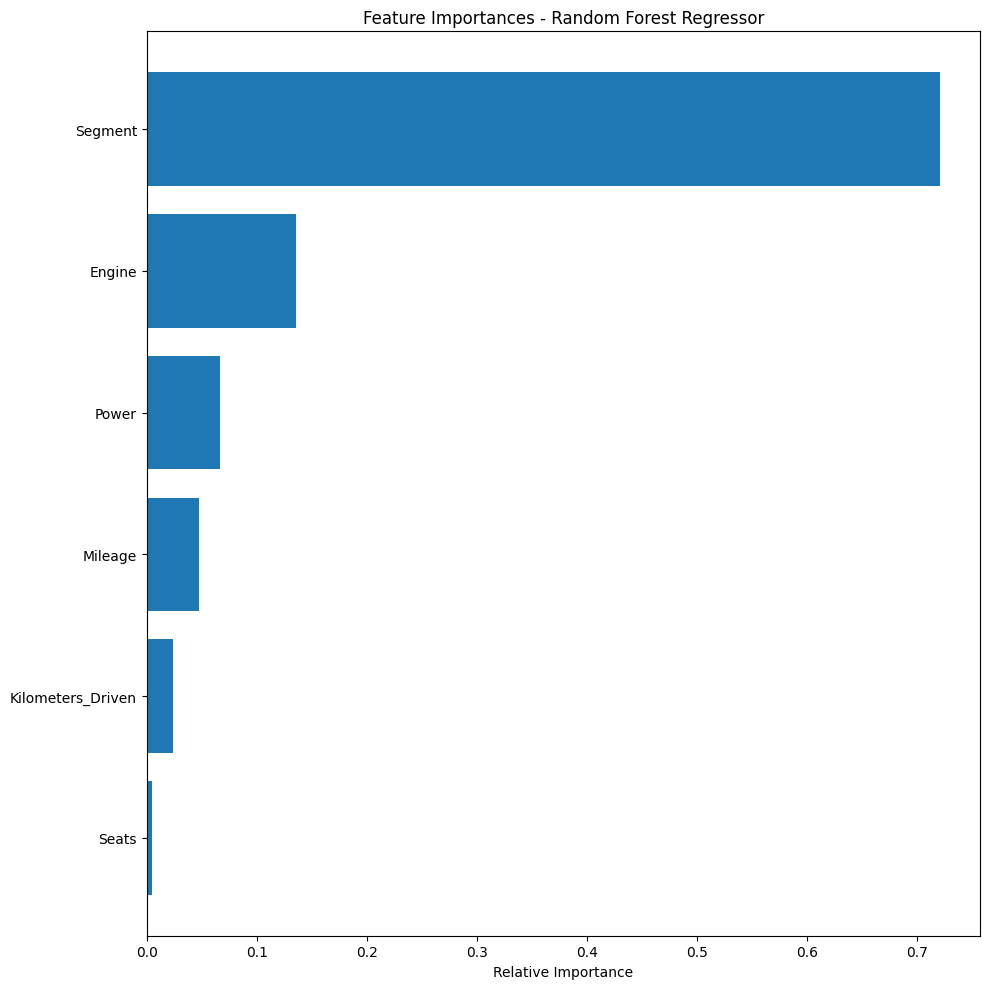

In [ ]:
# Import required libraries
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# Read the feature importance data generated from the Random Forest model
fi = pd.read_csv("./artifacts/training_step/artifacts/outputs/feature_importances.csv")

# Sort feature importances in ascending order for better visualization
idx = np.argsort(fi["importance"].values)

# Set figure size for the plot
plt.figure(figsize=(10, 10))

# Create a horizontal bar chart to display feature importances
plt.barh(range(len(idx)), fi["importance"].values[idx], align="center")

# Set y-axis labels to feature names
plt.yticks(range(len(idx)), fi["feature"].values[idx])

# Label x-axis
plt.xlabel("Relative Importance")

# Add a descriptive title to the chart
plt.title("Feature Importances - Random Forest Regressor")

# Adjust layout to prevent label overlap
plt.tight_layout()

# Display the plot
plt.show()

**Observations**

* Segment is the most influential predictor of vehicle price, indicating strong differentiation across categories (e.g., luxury vs. non-luxury).

* Engine shows higher relative importance than Power, unlike the correlation analysis where Power had a stronger direct relationship with price.

* This shift suggests that within the model’s multivariate context, Engine capacity explains more price variance when considered alongside other predictors like Segment and Mileage.

* Segment and Engine together capture the majority of the variation in vehicle prices.

* Mileage, Kilometers Driven, and Seats contribute relatively less to the model’s predictive performance.

In [ ]:
# Access pipeline outputs (optional, after job completion)
print(f"Train data location: {pipeline_job.outputs['pipeline_job_train_data']}")
print(f"Test data location: {pipeline_job.outputs['pipeline_job_test_data']}")
print(f"Best model location: {pipeline_job.outputs['pipeline_job_best_model']}")

Train data location: ${{parent.outputs.pipeline_job_train_data}}
Test data location: ${{parent.outputs.pipeline_job_test_data}}
Best model location: ${{parent.outputs.pipeline_job_best_model}}


## **5. Actionable Insights and Recommendations**

### **5.1 Actionable Insights**

* The Random Forest Regressor achieved an Adjusted R² of 0.94, explaining nearly all price variance and confirming strong predictive reliability.

* Segment is the dominant factor influencing vehicle price, followed by Engine capacity, showing that classification and performance are primary pricing drivers.

* Engine followed closely, carrying more predictive weight than Power , unlike in the correlation analysis , suggesting that engine capacity better captures performance-driven price differences when other features are considered.

* Mileage and Kilometers Driven negatively influence price, validating the depreciation effect across both segments.

* Collectively, these findings establish a solid foundation for automating pricing decisions using model-driven intelligence.

### **5.2 Recommendations**

* Integrate the Random Forest model into the dealership’s pricing workflow to enable automated, consistent, and data-driven valuation of used vehicles.

* Emphasize Segment and Engine capacity in pricing strategies while dynamically adjusting for Mileage to reflect vehicle depreciation.

* Leverage the MLOps pipeline for continuous training, model versioning, and deployment, ensuring scalability and reduced manual intervention.

* Deploy a real-time valuation dashboard to allow business users and analysts to visualize predicted prices and monitor model performance.

* Retrain the model periodically using updated vehicle and market data to maintain predictive accuracy and responsiveness to evolving trends.

## **6. Github Artifacts**

**Link to the GitHub repository containing the GitHub Actions workflow**

https://github.com/oretunde/mls17-Oct25

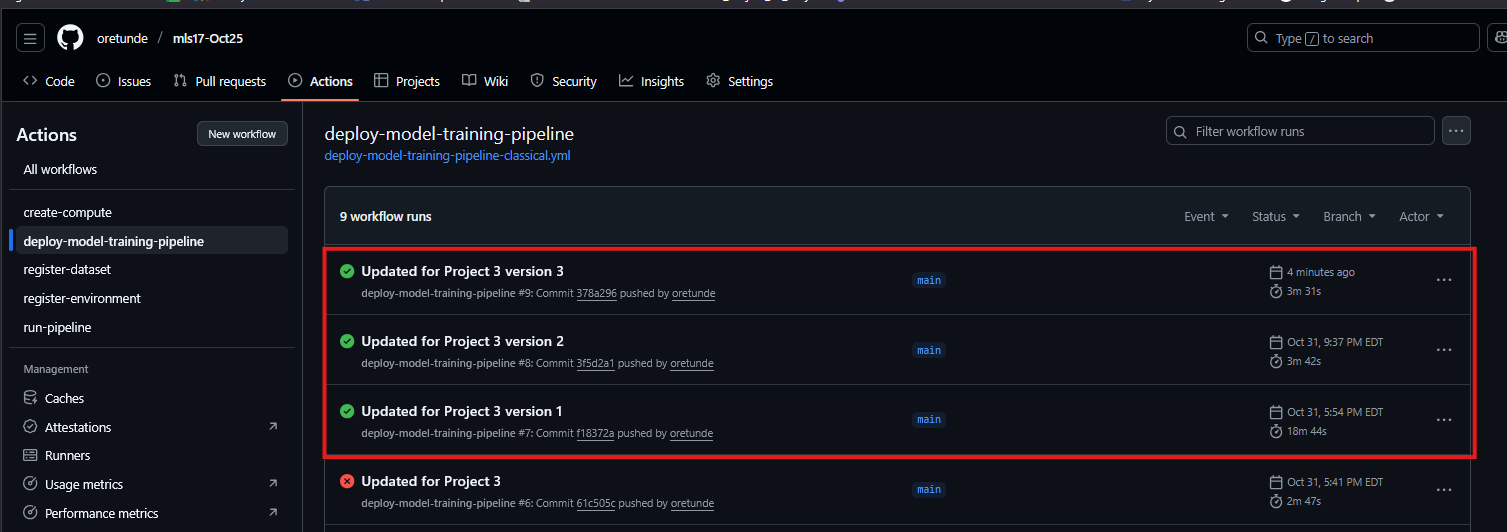

In [ ]:
from IPython import display
display.Image("artifacts/images/Gitgub_Actions_Workflow_Overview.png")

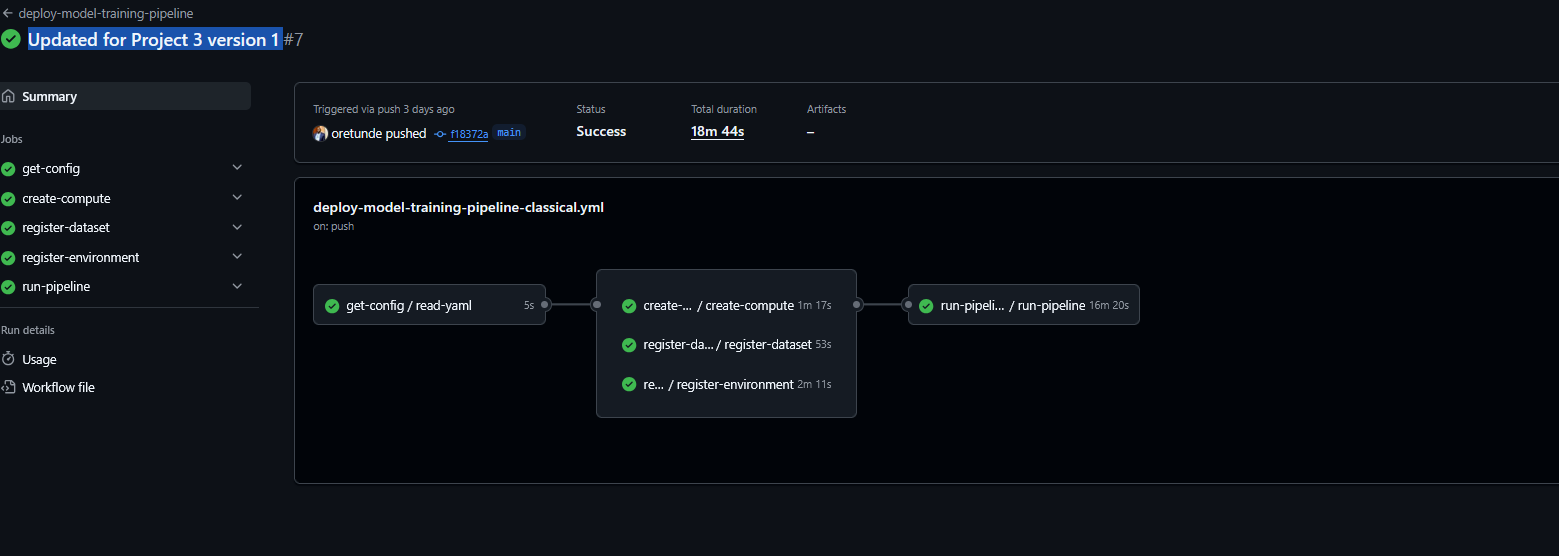

In [ ]:
from IPython import display
display.Image("artifacts/images/Updated for Project 3 version 1.png")

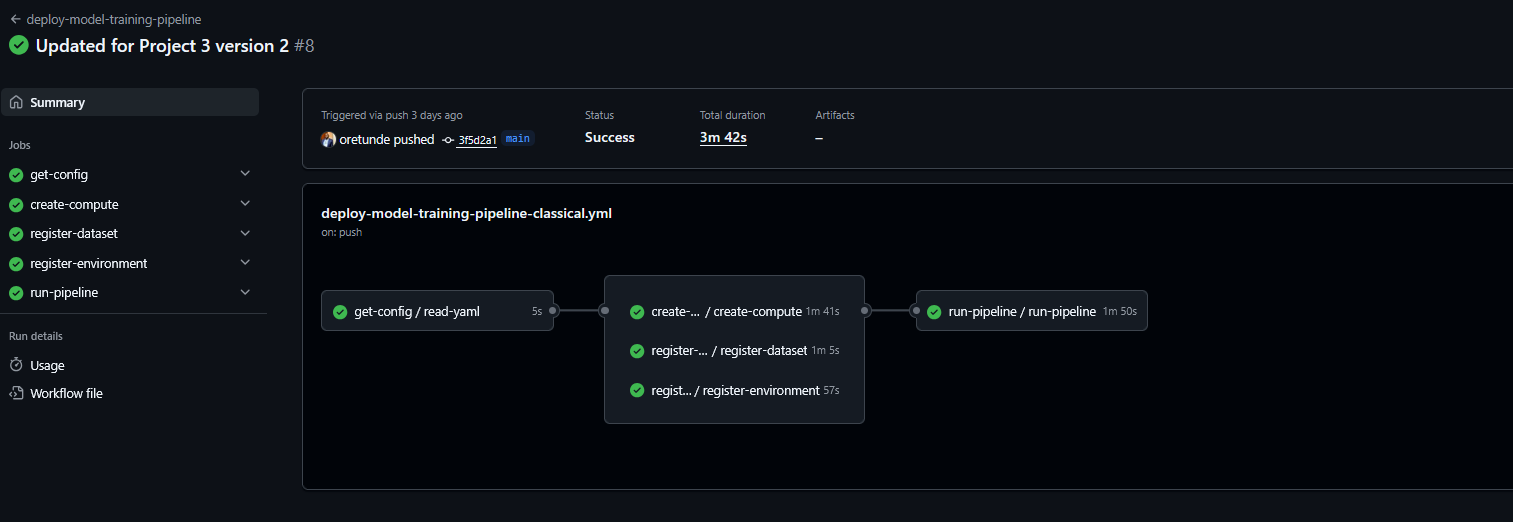

In [ ]:
from IPython import display
display.Image("artifacts/images/Updated for Project 3 version 2.png")

**Validation of CICD Implementation**

* Updated the used_cars.csv
* Commit the changes to the GitHub repo to validate CICD implementation

In [ ]:
from IPython import display
display.Image("artifacts/images/Commit_CICD_pipeline_validation.png")

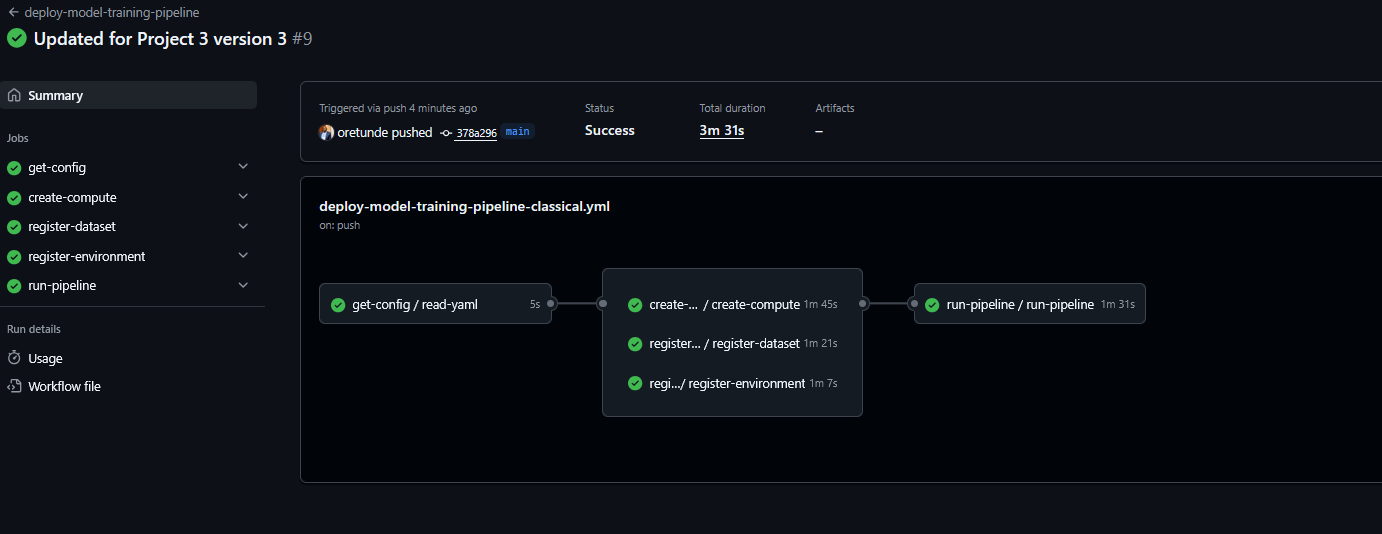

In [ ]:
from IPython import display
display.Image("artifacts/images/Updated for Project 3 version 3.png")